# Simulación del Problema Gravitacional de N Cuerpos
#
**Proyecto 1 — Astrofísica Computacional**
#
Motor de simulación gravitacional propio (sin librerías de EDOs externas) que cubre las
cuatro fases del proyecto:
#
- **Fase I** — Diferenciación numérica (fórmulas de 3 puntos, caso s=1) verificadas numéricamente.
- **Fase II** — Integradores RK4 y simpléctico, solver de Kepler, parser de TLE,
  interpolación de Lagrange y detección de eventos por bisección (prueba del cruce 2.667).
- **Fase III** — Tarea 1 (Tierra-ISS con TLE real + benchmark analítico), Tarea 2
  (Tierra-Luna + puntos de Lagrange L2/L4), Tarea 3 (sistema solar interior 3D con
  Mercurio a 7°, precesión y comparación 2D vs 3D).
- **Fase IV** — Conservación de E, L y P; deriva medida vs error teórico E'₃; justificación de h.
#
**Estructura**: cada celda define un módulo independiente; al final, el *Bloque de
ejecución integral* ensambla todos los módulos y ejecuta el proyecto completo como un
único programa (`main()`). Las esferas de las figuras "a escala" están magnificadas por
los factores indicados en cada leyenda; **las trayectorias siempre están a escala real**.

## Fase I: Diferenciación numérica
#
Fórmula general de 3 puntos para la primera derivada (Ec. 0.4 del enunciado) y fórmula
de la segunda derivada (Ec. 0.5). Se verifican numéricamente: en particular, que con
$s=1$ la fórmula general se reduce exactamente a la diferencia central estándar.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def primera_derivada_3_puntos(f0, f1, f2, h, s=1.0):
    """
    Fórmula general de la primera derivada con tres puntos (n=2, Ec. 0.4).

    f0, f1, f2 : valores de f en x0, x1=x0+h, x2=x0+2h
    h          : paso de malla
    s          : parámetro adimensional de posición (x = x0 + s·h)
    """
    return ((-3 + 2*s)*f0 + 4*(1 - s)*f1 + (-1 + 2*s)*f2) / (2*h)

def segunda_derivada_3_puntos(f0, f1, f2, h):
    """Segunda derivada finita de tres puntos (Ec. 0.5)."""
    return (f0 - 2*f1 + f2) / h**2

# --- Verificación inmediata: s=1 recupera la diferencia central (requisito Fase I) ---
f_test = lambda x: np.sin(x)
x1, h_test = 0.7, 1e-3
f0_t, f1_t, f2_t = f_test(x1 - h_test), f_test(x1), f_test(x1 + h_test)

diferencia_central = (f2_t - f0_t) / (2*h_test)
general_s1 = primera_derivada_3_puntos(f0_t, f1_t, f2_t, h_test, s=1.0)

print(f"Analítica            f'({x1}) = {np.cos(x1):.12f}")
print(f"Diferencia central           = {diferencia_central:.12f}  (error {abs(diferencia_central-np.cos(x1)):.2e})")
print(f"Fórmula general con s=1      = {general_s1:.12f}  (error {abs(general_s1-np.cos(x1)):.2e})")
print(f"¿Idénticas s=1 ≡ central?    -> {np.isclose(general_s1, diferencia_central, rtol=0, atol=1e-16)}")

Analítica            f'(0.7) = 0.764842187284
Diferencia central           = 0.764842059811  (error 1.27e-07)
Fórmula general con s=1      = 0.764842059811  (error 1.27e-07)
¿Idénticas s=1 ≡ central?    -> True


## Fase II — Módulo 1: constantes, potencial gravitacional y magnitudes conservadas
#
La aceleración incluye el parámetro de suavizado $\epsilon$ (Ec. de Plummer). Para este
proyecto se usa $\epsilon = 0$ (masas puntuales en sistemas jerárquicos, sin encuentros
cercanos), de modo que se recupera la ley newtoniana exacta.

In [16]:
# --- Constantes físicas ---
G = 6.67430e-11             # m^3 kg^-1 s^-2 (constante gravitacional universal)
MU_TIERRA = 3.986004418e14  # m^3/s^2 (μ = G·M_Tierra, estándar usado por los TLE)
M_SOL = 1.989e30            # kg
M_T = 5.972e24              # kg
M_L = 7.342e22              # kg
R_T = 6371e3                # m (radio terrestre)
R_L = 1737.4e3              # m (radio lunar)
D_TL = 384400e3             # m (distancia Tierra-Luna)
MU_SOL = G*M_SOL            # m^3/s^2
MU_MARTE = G*6.417e23       # m^3/s^2

def calcular_aceleraciones(masas, posiciones, G=G, epsilon=0.0):
    """
    Aceleración gravitacional 3D de N cuerpos (módulo independiente del integrador).

    masas      : (N,)   masas
    posiciones : (N, 3) posiciones cartesianas
    epsilon    : longitud de suavizado (0 = newtoniano exacto)
    """
    N = len(masas)
    aceleraciones = np.zeros((N, 3))
    for i in range(N):
        r_vectores = posiciones[i] - posiciones              # r_ij
        distancias = np.linalg.norm(r_vectores, axis=1)
        distancias[i] = np.inf                               # excluir el término i=j
        factor = G * masas / (distancias**2 + epsilon**2)**1.5
        aceleraciones[i] = -np.sum(factor[:, np.newaxis] * r_vectores, axis=0)
    return aceleraciones

def calcular_energia_potencial(masas, posiciones, G=G):
    """Energía potencial gravitacional total (suma de pares)."""
    N = len(masas)
    U = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            U -= G * masas[i] * masas[j] / np.linalg.norm(posiciones[i] - posiciones[j])
    return U

def calcular_energia_total(masas, posiciones, velocidades, G=G):
    """E = K + U."""
    K = 0.5 * np.sum(masas[:, None] * velocidades**2)
    return K + calcular_energia_potencial(masas, posiciones, G)

def calcular_momento_angular(masas, posiciones, velocidades):
    """Vector de momento angular total L = Σ m_i (r_i × v_i)."""
    return np.sum(masas[:, None] * np.cross(posiciones, velocidades), axis=0)

def calcular_momento_lineal(masas, velocidades):
    """Vector de momento lineal total P = Σ m_i v_i."""
    return np.sum(masas[:, None] * velocidades, axis=0)

## Fase II — Módulo 2: integradores numéricos (RK4 y Verlet velocidad)

In [17]:
def paso_rk4(masas, posiciones, velocidades, h, G=G):
    """Un paso de Runge-Kutta de 4.º orden (error local O(h^5))."""
    v_k1, a_k1 = velocidades, calcular_aceleraciones(masas, posiciones, G)
    v_k2 = velocidades + 0.5*h*a_k1
    a_k2 = calcular_aceleraciones(masas, posiciones + 0.5*h*v_k1, G)
    v_k3 = velocidades + 0.5*h*a_k2
    a_k3 = calcular_aceleraciones(masas, posiciones + 0.5*h*v_k2, G)
    v_k4 = velocidades + h*a_k3
    a_k4 = calcular_aceleraciones(masas, posiciones + h*v_k3, G)
    pos_n = posiciones + (h/6.0)*(v_k1 + 2*v_k2 + 2*v_k3 + v_k4)
    vel_n = velocidades + (h/6.0)*(a_k1 + 2*a_k2 + 2*a_k3 + a_k4)
    return pos_n, vel_n

def paso_simplectico(masas, posiciones, velocidades, accel, h, G=G):
    """Un paso de Verlet velocidad (Kick-Drift-Kick), simpléctico de orden 2."""
    v_media = velocidades + 0.5*h*accel
    pos_n = posiciones + h*v_media
    a_n = calcular_aceleraciones(masas, pos_n, G)
    vel_n = v_media + 0.5*h*a_n
    return pos_n, vel_n, a_n

## Fase II — Módulo 3: ecuación de Kepler, elementos orbitales y parser de TLE
#
Solución analítica del problema de dos cuerpos: solver de Newton-Raphson para
$M = E - e\sin E$, transformación de elementos Keplerianos a cartesianos (con
$\arctan_2$, robusta en todos los cuadrantes) y parser de TLE para la Tarea 1.

In [18]:
def resolver_anomalia_excentrica(M_rad, e, tol=1e-12, max_iter=100):
    """Newton-Raphson para la ecuación de Kepler M = E - e·sin(E)."""
    M_rad = np.mod(M_rad, 2*np.pi)
    E = M_rad if e < 0.8 else np.pi
    for _ in range(max_iter):
        f = E - e*np.sin(E) - M_rad
        dE = f / (1.0 - e*np.cos(E))
        E -= dE
        if abs(dE) < tol:
            break
    return E

def kepler_a_cartesiano(a, e, i_deg, Omega_deg, omega_deg, M_deg, mu):
    """Elementos Keplerianos (ángulos en grados) -> vectores de estado (r, v)."""
    i, O, w = np.radians([i_deg, Omega_deg, omega_deg])
    E = resolver_anomalia_excentrica(np.radians(M_deg), e)
    
    #se halla la animalía verdadera
    nu = 2.0*np.arctan2(np.sqrt(1.0 + e)*np.sin(E/2.0), np.sqrt(1.0 - e)*np.cos(E/2.0))
    #ecuaciones de Kepler
    r_mag = a*(1.0 - e*np.cos(E))
    r_orb = np.array([r_mag*np.cos(nu), r_mag*np.sin(nu), 0.0])

    p = a*(1.0 - e**2)
    h_mag = np.sqrt(mu*p)
    #vis-viva ec
    v_orb = np.array([-(mu/h_mag)*np.sin(nu), (mu/h_mag)*(e + np.cos(nu)), 0.0])

    R3_O = np.array([[np.cos(O), -np.sin(O), 0], [np.sin(O), np.cos(O), 0], [0, 0, 1]])
    R1_i = np.array([[1, 0, 0], [0, np.cos(i), -np.sin(i)], [0, np.sin(i), np.cos(i)]])
    R3_w = np.array([[np.cos(w), -np.sin(w), 0], [np.sin(w), np.cos(w), 0], [0, 0, 1]])
    Q = R3_O @ R1_i @ R3_w
    return Q @ r_orb, Q @ v_orb

def propagar_kepler_analitico(a, e, i_deg, Omega_deg, omega_deg, M0_deg, n_rad_s, t_array, mu):
    """Posición Kepleriana exacta en cada t (solución analítica de referencia)."""
    pos = np.zeros((len(t_array), 3))
    for k, t in enumerate(t_array):
        M_k = M0_deg + np.degrees(n_rad_s * t)
        r, _ = kepler_a_cartesiano(a, e, i_deg, Omega_deg, omega_deg, M_k, mu)
        pos[k] = r
    return pos

def parse_tle(linea1, linea2):
    """
    Extrae (a, e, i, Omega, omega, M0, n) de un TLE estándar.
    a en metros, n en rad/s; ángulos en grados. Usa mu = G·M_Tierra.
    """
    e = float("0." + linea2[26:33].strip())
    i_deg = float(linea2[8:16])
    Omega_deg = float(linea2[17:25])
    omega_deg = float(linea2[34:42])
    M0_deg = float(linea2[43:51])
    n_rev_dia = float(linea2[52:63])
    n_rad_s = n_rev_dia * 2*np.pi / 86400.0
    a = (MU_TIERRA / n_rad_s**2)**(1.0/3.0)
    return a, e, i_deg, Omega_deg, omega_deg, M0_deg, n_rad_s

## Fase II — Módulo 4: interpolación de Lagrange y detección de eventos (bisección)
#
Incluye la prueba de verificación exigida por el enunciado: detectar la constante de
cruce 2.667 en un caso unit-normalizado.

In [19]:
def interpolador_lagrange(t_eval, t_points, state_points):
    """Interpolación polinomial de Lagrange del vector de estado entre nodos discretos."""
    t_eval = np.atleast_1d(t_eval)
    n = len(t_points)
    salida = np.zeros((len(t_eval),) + np.shape(state_points[0]))
    for idx, t in enumerate(t_eval):
        estado = np.zeros_like(np.asarray(state_points[0], dtype=float))
        for j in range(n):
            l_j = 1.0
            for m in range(n):
                if m != j:
                    l_j *= (t - t_points[m]) / (t_points[j] - t_points[m])
            estado += l_j * state_points[j]
        salida[idx] = estado
    return salida if len(t_eval) > 1 else salida[0]

def buscar_raiz_biseccion(func_objetivo, t_a, t_b, tol=1e-10, max_iter=200):
    """Método de bisección: encuentra t* con f(t*) = 0 en [t_a, t_b] (Bolzano)."""
    f_a, f_b = func_objetivo(t_a), func_objetivo(t_b)
    if f_a * f_b > 0:
        raise ValueError("El intervalo no contiene un cambio de signo.")
    t_izq, t_der = t_a, t_b
    for _ in range(max_iter):
        t_medio = 0.5*(t_izq + t_der)
        f_medio = func_objetivo(t_medio)
        if abs(f_medio) < tol or 0.5*(t_der - t_izq) < tol:
            return t_medio
        if f_a * f_medio < 0:
            t_der = t_medio
        else:
            t_izq, f_a = t_medio, f_medio
    return 0.5*(t_izq + t_der)

# --- Prueba unitaria exigida: constante de cruce 2.667 (caso unit-normalizado) ---
g_prueba = lambda x: x**3 - 2.667**3
raiz_2667 = buscar_raiz_biseccion(g_prueba, 0.0, 5.0, tol=1e-12)
print(f"Prueba de bisección: raíz detectada = {raiz_2667:.12f} (esperada 2.667)")
assert abs(raiz_2667 - 2.667) < 1e-9, "FALLÓ la verificación del cruce 2.667"
print("Verificación del cruce 2.667: PASA ✔")

Prueba de bisección: raíz detectada = 2.667000000000 (esperada 2.667)
Verificación del cruce 2.667: PASA ✔


## Fase II — Módulo 5: registro por paso, elementos osculantes y errores teóricos

In [20]:
def simular_y_registrar(masas, pos_ini, vel_ini, t_final, h, G=G, integrador='rk4'):
    """Integra el sistema y registra t, estados, E, L y P en cada paso."""
    pasos = int(np.ceil(t_final / h))
    N = len(masas)
    log = {
        't': np.zeros(pasos), 'pos': np.zeros((pasos, N, 3)), 'vel': np.zeros((pasos, N, 3)),
        'E': np.zeros(pasos), 'L': np.zeros((pasos, 3)), 'P': np.zeros((pasos, 3)),
    }
    pos, vel = np.copy(pos_ini), np.copy(vel_ini)
    accel = calcular_aceleraciones(masas, pos, G)
    for i in range(pasos):
        log['t'][i] = i*h
        log['pos'][i], log['vel'][i] = pos, vel
        log['E'][i] = calcular_energia_total(masas, pos, vel, G)
        log['L'][i] = calcular_momento_angular(masas, pos, vel)
        log['P'][i] = calcular_momento_lineal(masas, vel)
        if integrador == 'rk4':
            pos, vel = paso_rk4(masas, pos, vel, h, G)
        elif integrador == 'simplectico':
            pos, vel, accel = paso_simplectico(masas, pos, vel, accel, h, G)
        else:
            raise ValueError("Integrador no reconocido.")
    return log

def elementos_osculantes(pos_rel, vel_rel, mu):
    """
    Elementos osculadores (a, e, i, Omega, omega, varpi) de una trayectoria
    relativa a la primaria. Entradas (pasos, 3). Robusto también en el caso plano (i = 0).
    """
    r = np.linalg.norm(pos_rel, axis=1)
    h_vec = np.cross(pos_rel, vel_rel)
    h_mag = np.linalg.norm(h_vec, axis=1)
    e_vec = np.cross(vel_rel, h_vec)/mu - pos_rel/r[:, None]
    e_mag = np.linalg.norm(e_vec, axis=1)
    a = -mu / (2*(0.5*np.sum(vel_rel**2, axis=1) - mu/r))

    n_vec = np.cross(np.array([0.0, 0.0, 1.0]), h_vec)   # línea de nodos
    n_mag = np.linalg.norm(n_vec, axis=1)
    plano = n_mag < 1e-9                                  # órbita plana: nodo indefinido
    n_vec[plano] = np.array([1.0, 0.0, 0.0])
    n_mag[plano] = 1.0

    inc = np.arccos(np.clip(h_vec[:, 2]/h_mag, -1, 1))
    Omega = np.arctan2(n_vec[:, 1], n_vec[:, 0]) % (2*np.pi)
    sin_w = np.sum(np.cross(n_vec, e_vec)*h_vec, axis=1)/(n_mag*e_mag*h_mag)
    cos_w = np.sum(n_vec*e_vec, axis=1)/(n_mag*e_mag)
    omega = np.arctan2(sin_w, cos_w) % (2*np.pi)

    varpi = np.unwrap(Omega + omega)
    return {'a': a, 'e': e_mag, 'i': np.degrees(inc),
            'Omega': np.degrees(np.unwrap(Omega)), 'omega': np.degrees(np.unwrap(omega)),
            'varpi': np.degrees(varpi)}

def error_truncamiento_e3(h, s, f_cuarta_derivada_xi):
    """Error de truncamiento teórico E'_3 (Ec. 0.7 del enunciado)."""
    return -(h**3)/12.0 * (3 - 11*s + 9*s**2 - 2*s**3) * f_cuarta_derivada_xi

def estimar_f4(mu, r):
    """Cota de |f^(iv)| para órbita cuasi-circular: 8·(GM)^2 / r^5  (deriva en el informe)."""
    return 8.0 * mu**2 / r**5

## Fase II — Módulo 6: utilidades de visualización
#
Nota de honestidad visual: en las figuras "a escala" las **trayectorias** se dibujan
siempre en unidades reales; solo el **tamaño de las esferas** se magnifica por un factor
explícito (indicado en cada leyenda) para que los cuerpos sean visibles.

In [21]:
def graficar_esfera(ax, radio, centro, color, n=30, alpha=0.8):
    """Dibuja una esfera (superficie de revolución) en un Axes3D."""
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)
    x = centro[0] + radio*np.outer(np.cos(u), np.sin(v))
    y = centro[1] + radio*np.outer(np.sin(u), np.sin(v))
    z = centro[2] + radio*np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0)

def fijar_escala_3d_igual(ax):
    """Fuerza los tres ejes a la misma escala (caja cúbica) para evitar deformaciones."""
    ax.set_box_aspect([1, 1, 1])
    xl, yl, zl = ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()
    rangos = [(l[1]-l[0], np.mean(l)) for l in (xl, yl, zl)]
    max_r = max(r for r, _ in rangos)/2.0
    for set_lim, (_, m) in zip((ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d), rangos):
        set_lim([m - max_r, m + max_r])

def graficar_conservacion(log, titulo, nombre_archivo):
    """Suite de validación multipanel: ΔE/|E0|, Δ|L|/|L0| y componentes de L."""
    t_dias = log['t']/86400
    E, L = log['E'], log['L']
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    ax1.plot(t_dias, (E - E[0])/abs(E[0]), 'r-', lw=1)
    ax1.set_ylabel(r'$\Delta E / |E_0|$'); ax1.set_title(titulo)
    ax1.grid(True, alpha=0.5)
    ax2.plot(t_dias, np.linalg.norm(L, axis=1)/np.linalg.norm(L[0]) - 1, 'b-', lw=1)
    ax2.set_ylabel(r'$\Delta |L| / |L_0|$'); ax2.grid(True, alpha=0.5)
    ax3.plot(t_dias, L[:, 0], '--', label=r'$L_x$', alpha=0.6)
    ax3.plot(t_dias, L[:, 1], '--', label=r'$L_y$', alpha=0.6)
    ax3.plot(t_dias, L[:, 2], '--', label=r'$L_z$', alpha=0.6)
    ax3.set_ylabel('Componentes de L'); ax3.set_xlabel('Tiempo (días)')
    ax3.legend(); ax3.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

## Fase III — Tarea 1: benchmark analítico de 2 cuerpos (Tierra + ISS)
#
Condiciones iniciales de un **TLE real y reciente** de la ISS (Celestrak, época
2026-10-09 19:42 UTC). La propagación RK4 se compara contra la **solución Kepleriana
analítica exacta** durante **100 períodos orbitales** (deriva del solver), se analiza el
escalado con $h$, se detectan los ápsides con Lagrange+bisección y se generan las
figuras — incluida la vista a **escala real 1:1**.

In [22]:
def ejecutar_tarea_1():
    """Tarea 1 completa. Devuelve un diccionario con los resultados para la Fase IV."""
    # --- TLE de la ISS (ZARYA), NORAD 25544. Fuente: https://celestrak.org ---
    TLE_L1 = "1 25544U 98067A   26282.82140207  .00006479  00000+0  12652-3 0  9998"
    TLE_L2 = "2 25544  51.6314  92.7969 0006775 242.6225 117.4075 15.48793003589526"

    a_iss, e_iss, i_iss, Om_iss, w_iss, M0_iss, n_iss = parse_tle(TLE_L1, TLE_L2)
    T_iss = 2*np.pi/n_iss
    print(f"TLE ISS (época 2026-10-09): a = {a_iss/1000:.3f} km, e = {e_iss:.7f}, "
          f"i = {i_iss}°, T = {T_iss/60:.2f} min")

    # Estado inicial Kepleriano geocéntrico -> marco baricéntrico.
    # Consistencia de μ: el TLE se reduce con MU_TIERRA; usar G·(5.972e24) en cambio
    # introduce un sesgo sistemático de ~240 km en 100 órbitas.
    r0_iss, v0_iss = kepler_a_cartesiano(a_iss, e_iss, i_iss, Om_iss, w_iss, M0_iss, MU_TIERRA)
    m_iss = 419725.0
    M_Tierra_sim = MU_TIERRA/G
    M_sistema = M_Tierra_sim + m_iss
    pos_ini = np.array([-(m_iss/M_sistema)*r0_iss, (M_Tierra_sim/M_sistema)*r0_iss])
    vel_ini = np.array([-(m_iss/M_sistema)*v0_iss, (M_Tierra_sim/M_sistema)*v0_iss])
    masas = np.array([M_Tierra_sim, m_iss])

    # --- Integración: 100 períodos con RK4 (h = 15 s) ---
    h_T1 = 15.0
    t_final = 100.0*T_iss
    print(f"Integrando 100 períodos ({t_final/86400:.3f} días) con h = {h_T1} s ...")
    log_T1 = simular_y_registrar(masas, pos_ini, vel_ini, t_final, h_T1, integrador='rk4')

    r_rel_num = log_T1['pos'][:, 1, :] - log_T1['pos'][:, 0, :]
    v_rel_num = log_T1['vel'][:, 1, :] - log_T1['vel'][:, 0, :]
    r_rel_ana = propagar_kepler_analitico(a_iss, e_iss, i_iss, Om_iss, w_iss,
                                          M0_iss, n_iss, log_T1['t'], MU_TIERRA)
    deriva = np.linalg.norm(r_rel_num - r_rel_ana, axis=1)
    print(f"Deriva máxima en 100 períodos: {deriva.max():.3f} m")

    n_plot = int(T_iss/h_T1)

    # --- Fig: órbita 3D numérica vs analítica ---
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.computed_zorder = False
    graficar_esfera(ax, R_T/1e3, np.zeros(3), 'royalblue', alpha=0.35)
    ax.plot(r_rel_num[:n_plot, 0]/1e3, r_rel_num[:n_plot, 1]/1e3, r_rel_num[:n_plot, 2]/1e3,
            'g-', lw=2.0, label='ISS (numérica, 1 órbita)')
    ax.plot(r_rel_ana[:n_plot, 0]/1e3, r_rel_ana[:n_plot, 1]/1e3, r_rel_ana[:n_plot, 2]/1e3,
            'r--', lw=1.5, label='Kepler analítica')
    r_lim = 1.35*a_iss/1e3
    ax.set_xlim([-r_lim, r_lim]); ax.set_ylim([-r_lim, r_lim]); ax.set_zlim([-r_lim, r_lim])
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)'); ax.set_zlabel('z (km)')
    ax.set_title(f'Tarea 1: Órbita ISS desde TLE (i = {i_iss}°, e = {e_iss:.5f})')
    ax.legend()
    fijar_escala_3d_igual(ax)
    plt.tight_layout()
    plt.savefig("T1v2_01_Orbita_3D.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: escala real 1:1 (Tierra a escala; la órbita LEO apenas roza la superficie) ---
    fig = plt.figure(figsize=(13, 5.5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.computed_zorder = False
    graficar_esfera(ax1, R_T/1e3, np.zeros(3), 'royalblue', alpha=0.9)
    ax1.plot(r_rel_num[:n_plot, 0]/1e3, r_rel_num[:n_plot, 1]/1e3, r_rel_num[:n_plot, 2]/1e3,
             'g-', lw=2.0)
    r1_lim = 1.12*a_iss/1e3
    ax1.set_xlim([-r1_lim, r1_lim]); ax1.set_ylim([-r1_lim, r1_lim]); ax1.set_zlim([-r1_lim, r1_lim])
    ax1.set_xlabel('x (km)'); ax1.set_ylabel('y (km)'); ax1.set_zlabel('z (km)')
    ax1.set_title('Escala real 1:1 (3D)')
    fijar_escala_3d_igual(ax1)

    ax2 = fig.add_subplot(122)
    ax2.add_patch(plt.Circle((0, 0), R_T/1e3, color='royalblue', alpha=0.9))
    ax2.plot(r_rel_num[:n_plot, 0]/1e3, r_rel_num[:n_plot, 1]/1e3, 'g-', lw=1.5)
    ax2.set_aspect('equal')
    ax2.set_xlabel('x (km)'); ax2.set_ylabel('y (km)')
    ax2.set_title(f'Proyección XY (escala real)\nAltitud media ≈ {(a_iss - R_T)/1000:.0f} km')
    ax2.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig("T1v2_06_Escala_Real.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: proyecciones de la órbita en los tres planos (escala real) ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (nombre, c1, c2) in zip(axs, [('XY', 0, 1), ('XZ', 0, 2), ('YZ', 1, 2)]):
        ax.add_patch(plt.Circle((0, 0), R_T/1e3, color='royalblue', alpha=0.9))
        ax.plot(r_rel_num[:n_plot, c1]/1e3, r_rel_num[:n_plot, c2]/1e3, 'g-', lw=1.2)
        ax.set_aspect('equal')
        ax.set_xlabel(f'{nombre[0]} (km)'); ax.set_ylabel(f'{nombre[1]} (km)')
        ax.set_title(f'Plano {nombre}')
        ax.grid(True, linestyle=':', alpha=0.6)
    plt.suptitle('Tarea 1: proyecciones de la órbita de la ISS (escala real)', y=1.02)
    plt.tight_layout()
    plt.savefig("T1v2_07_Planos.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: deriva vs analítica ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    t_orb = log_T1['t']/T_iss
    ax1.plot(t_orb, deriva, 'b-', lw=1.5)
    ax1.set_xlabel('Número de períodos orbitales'); ax1.set_ylabel('Deriva de posición (m)')
    ax1.set_title(f'Deriva RK4 vs Kepler analítica (h = {h_T1} s)')
    ax1.grid(True, alpha=0.5)
    r_num_mag = np.linalg.norm(r_rel_num, axis=1)
    ax2.plot(t_orb, (r_num_mag - np.linalg.norm(r_rel_ana, axis=1))/1e3, 'b-', lw=1.5)
    ax2.set_xlabel('Número de períodos orbitales'); ax2.set_ylabel('r_num − r_ana (km)')
    ax2.set_title('Error radial (conserva la escala orbital)')
    ax2.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig("T1v2_02_Deriva_100T.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Conservación (T1) ---
    graficar_conservacion(log_T1, 'Tarea 1: Conservación (Tierra-ISS, RK4)', "T1v2_03_Conservacion.png")
    print(f"T1 RK4: ΔE/|E0| final = {(log_T1['E'][-1]-log_T1['E'][0])/abs(log_T1['E'][0]):.3e}, "
          f"Δ|L|/|L0| final = {np.linalg.norm(log_T1['L'][-1])/np.linalg.norm(log_T1['L'][0])-1:.3e}")

    # --- Validación Fase I: 2.ª derivada de 3 puntos reproduce las aceleraciones ---
    idx = np.arange(1, len(log_T1['t'])-1, 400)
    a_fd = np.array([segunda_derivada_3_puntos(r_rel_num[k-1], r_rel_num[k], r_rel_num[k+1], h_T1)
                     for k in idx])
    a_teo = np.array([-MU_TIERRA*r_rel_num[k]/np.linalg.norm(r_rel_num[k])**3 for k in idx])
    err_rel = np.linalg.norm(a_fd - a_teo, axis=1)/np.linalg.norm(a_teo, axis=1)
    print(f"Validación 2.ª derivada vs a = -μr/r³ : error relativo medio = {err_rel.mean():.3e} "
          f"(máx {err_rel.max():.3e})")

    # --- Barrido de h: deriva medida vs cota teórica E'3 ---
    h_lista = [10.0, 15.0, 30.0, 60.0]
    deriva_final = []
    for h_b in h_lista:
        log_b = simular_y_registrar(masas, pos_ini, vel_ini, t_final, h_b, integrador='rk4')
        r_b = log_b['pos'][:, 1, :] - log_b['pos'][:, 0, :]
        r_ana_b = propagar_kepler_analitico(a_iss, e_iss, i_iss, Om_iss, w_iss,
                                            M0_iss, n_iss, log_b['t'], MU_TIERRA)
        deriva_final.append(np.linalg.norm(r_b - r_ana_b, axis=1)[-1])
        print(f"h = {h_b:5.1f} s -> deriva final en 100T = {deriva_final[-1]:10.3f} m")

    f4_iss = estimar_f4(MU_TIERRA, a_iss)
    N_pasos = [t_final/h_b for h_b in h_lista]
    deriva_teorica = [abs(error_truncamiento_e3(h_b, 1.0, f4_iss))*N for h_b, N in zip(h_lista, N_pasos)]
    pendiente = np.polyfit(np.log(h_lista), np.log(deriva_final), 1)[0]
    print(f"\n|f4| ISS = {f4_iss:.3e} m/s^4 | pendiente log-log medida: p = {pendiente:.2f} (RK4 ≈ 4)")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(h_lista, deriva_final, 'bo-', label='Deriva medida (RK4, 100T)')
    ax.loglog(h_lista, deriva_teorica, 'rs--', label="Cota teórica E'₃ (Ec. 0.7)")
    ax.loglog(h_lista, deriva_final[0]*(np.array(h_lista)/h_lista[0])**4, 'k:', alpha=0.6,
              label='Referencia $h^4$')
    ax.set_xlabel('Paso h (s)'); ax.set_ylabel('Deriva de posición tras 100T (m)')
    ax.set_title('Tarea 1: Análisis de error y selección de h')
    ax.legend(); ax.grid(True, which='both', alpha=0.4)
    plt.tight_layout()
    plt.savefig("T1v2_04_Barrido_h.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Detección de eventos: ápsides con Lagrange + bisección ---
    rdot = np.sum(r_rel_num*v_rel_num, axis=1)

    def estado_interpolado(t):
        k = int(np.clip(np.searchsorted(log_T1['t'], t) - 2, 0, len(log_T1['t']) - 4))
        nodos_t = log_T1['t'][k:k+4]
        r_int = interpolador_lagrange(t, nodos_t, r_rel_num[k:k+4])
        v_int = interpolador_lagrange(t, nodos_t, v_rel_num[k:k+4])
        return r_int, v_int

    cambios = np.where(np.sign(rdot[:-1])*np.sign(rdot[1:]) < 0)[0]
    tiempos_apsides = np.array([buscar_raiz_biseccion(lambda tt: np.dot(*estado_interpolado(tt)),
                                                       log_T1['t'][k], log_T1['t'][k+1], tol=1e-8)
                                for k in cambios])
    r_apsides = np.array([np.linalg.norm(estado_interpolado(t)[0]) for t in tiempos_apsides])
    es_perigeo = np.zeros(len(tiempos_apsides), dtype=bool)
    es_perigeo[:-1] = r_apsides[:-1] < r_apsides[1:]
    es_perigeo[-1] = r_apsides[-1] < r_apsides[-2]
    espaciado = np.diff(tiempos_apsides)
    print(f"Ápsides: {len(tiempos_apsides)} ({es_perigeo.sum()} perigeos, {(~es_perigeo).sum()} apogeos) | "
          f"espaciado medio {espaciado.mean():.2f} s vs T/2 = {T_iss/2:.2f} s")
    print(f"r perigeo medio = {r_apsides[es_perigeo].mean()/1e3:.3f} km | "
          f"r apogeo medio = {r_apsides[~es_perigeo].mean()/1e3:.3f} km | "
          f"(TLE: a(1-e) = {a_iss*(1-e_iss)/1e3:.3f} km, a(1+e) = {a_iss*(1+e_iss)/1e3:.3f} km)")

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(log_T1['t']/T_iss, r_num_mag/1e3, 'b-', lw=1, label='r(t) numérica')
    ax.plot(tiempos_apsides/T_iss, r_apsides/1e3, 'r^', ms=8, label='Ápsides (Lagrange + bisección)')
    ax.set_xlabel('Períodos orbitales'); ax.set_ylabel('Distancia geocéntrica (km)')
    ax.set_title('Tarea 1: Detección de eventos — ápsides con interpolación sub-paso')
    ax.legend(); ax.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig("T1v2_05_Apsides.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    return {'log': log_T1, 'h_lista': h_lista, 'deriva_final': deriva_final,
            'deriva_teorica': deriva_teorica, 'pendiente': pendiente, 'f4_iss': f4_iss,
            'T': T_iss, 'espaciado_medio': espaciado.mean(), 'deriva_max': deriva.max()}

## Fase II — Módulo 7: puntos de Lagrange del problema circular restringido (CR3BP)
#
En el marco que rota con las dos primarias (unidades normalizadas: separación = 1,
masa total = 1, $\mu = m_2/(m_1+m_2)$, primarias en $(-\mu,0)$ y $(1-\mu,0)$), el
potencial efectivo es
$\Omega(x,y) = \tfrac12(x^2+y^2) + \frac{1-\mu}{r_1} + \frac{\mu}{r_2}$.
Los puntos de equilibrio son los **puntos críticos de $\Omega$**:
- $L_1, L_2, L_3$ (colineales): raíces de $\partial\Omega/\partial x = 0$, halladas
  **numéricamente por bisección** (reutiliza el Módulo 4) en intervalos con cambio de
  signo garantizado a cada lado de cada primaria.
- $L_4, L_5$ (triangulares): solución **exacta** — los vértices del triángulo
  equilátero construido sobre la línea de las primarias.

In [23]:
def puntos_lagrange_CR3BP(m1, m2, D):
    """
    Calcula los 5 puntos de Lagrange de un sistema de dos cuerpos (m1, m2 separados D).

    L1, L2, L3 (colineales): raíces de dΩ/dx = 0 resueltas por bisección.
    L4, L5 (triangulares): vértices del triángulo equilátero (solución exacta).

    Retorna un diccionario con las posiciones normalizadas (unidades CR3BP, marco
    rotante) y las posiciones físicas en metros (marco baricéntrico, primarias sobre
    el eje x, m2 del lado positivo).
    """
    mu = m2/(m1 + m2)

    def dOmega_dx(x):
        r1 = abs(x + mu)
        r2 = abs(x - 1 + mu)
        return x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3

    # Intervalos con cambio de signo garantizado alrededor de cada punto colineal
    x_L1 = buscar_raiz_biseccion(dOmega_dx, 0.0, 1 - mu - 1e-3, tol=1e-12)  # entre las primarias
    x_L2 = buscar_raiz_biseccion(dOmega_dx, 1 + 1e-3, 2.0, tol=1e-12)       # más allá de m2
    x_L3 = buscar_raiz_biseccion(dOmega_dx, -2.0, -mu - 1e-3, tol=1e-12)    # más allá de m1

    norm = {
        'L1': np.array([x_L1, 0.0]), 'L2': np.array([x_L2, 0.0]),
        'L3': np.array([x_L3, 0.0]),
        'L4': np.array([0.5 - mu, np.sqrt(3)/2]), 'L5': np.array([0.5 - mu, -np.sqrt(3)/2]),
    }
    fis = {k: np.array([p[0]*D, p[1]*D, 0.0]) for k, p in norm.items()}
    return {'mu': mu, 'puntos_norm': norm, 'puntos_fisicos': fis,
            'm1_norm': np.array([-mu, 0.0]), 'm2_norm': np.array([1 - mu, 0.0])}

## Fase III — Tarea 2: sistema restringido Tierra-Luna + puntos de Lagrange
#
5 cuerpos: Tierra, Luna, ISS (LEO circular), JWST en $L_2$ y satélite de prueba en
$L_4$. Incluye la vista del sistema con esferas magnificadas (Tierra/Luna ×8,
satélites con tamaño simbólico) y el zoom LEO a escala real.

In [24]:
def ejecutar_tarea_2():
    """Tarea 2 completa. Devuelve el registro de la simulación."""
    M_tot = M_T + M_L
    r_T_b = D_TL*(M_L/M_tot)
    r_L_b = D_TL*(M_T/M_tot)
    v_rel = np.sqrt(G*M_tot/D_TL)
    pos_Tierra = np.array([-r_T_b, 0.0, 0.0]); vel_Tierra = np.array([0.0, -v_rel*(M_L/M_tot), 0.0])
    pos_Luna = np.array([r_L_b, 0.0, 0.0]); vel_Luna = np.array([0.0, v_rel*(M_T/M_tot), 0.0])

    r_iss_leo = R_T + 400e3
    pos_ISS = pos_Tierra + np.array([r_iss_leo, 0, 0])
    vel_ISS = vel_Tierra + np.array([0, np.sqrt(G*M_T/r_iss_leo), 0])

    q = M_L/M_T
    r_h_L2 = D_TL*((q/3)**(1/3) + (1/3)*(q/3)**(2/3) - (1/9)*(q/3))
    omega_TL = np.sqrt(G*M_tot/D_TL**3)
    pos_JWST = pos_Luna + np.array([r_h_L2, 0, 0])
    vel_JWST = np.array([0, omega_TL*(pos_JWST[0] - pos_Tierra[0]), 0])

    R60 = np.array([[np.cos(np.pi/3), -np.sin(np.pi/3), 0],
                    [np.sin(np.pi/3), np.cos(np.pi/3), 0], [0, 0, 1]])
    r_EM, v_EM = pos_Luna - pos_Tierra, vel_Luna - vel_Tierra
    pos_L4 = pos_Tierra + R60 @ r_EM
    vel_L4 = vel_Tierra + R60 @ v_EM

    masas = np.array([M_T, M_L, 419725.0, 6161.0, 1000.0])
    pos_ini = np.array([pos_Tierra, pos_Luna, pos_ISS, pos_JWST, pos_L4])
    vel_ini = np.array([vel_Tierra, vel_Luna, vel_ISS, vel_JWST, vel_L4])

    h_T2, dias_T2 = 15.0, 28
    print(f"Integrando Tarea 2 (5 cuerpos, {dias_T2} días, h = {h_T2} s, RK4)...")
    log_T2 = simular_y_registrar(masas, pos_ini, vel_ini, dias_T2*86400, h_T2, integrador='rk4')

    # --- Fig: sistema 3D (trayectorias) ---
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i, (nombre, c, ls) in enumerate(zip(['Tierra', 'Luna', 'ISS', 'JWST (L2)', 'Satélite (L4)'],
                                            ['b', 'gray', 'g', 'r', 'purple'],
                                            ['-', '-', '-', '-', '--'])):
        ax.plot(log_T2['pos'][:, i, 0]/1e6, log_T2['pos'][:, i, 1]/1e6, log_T2['pos'][:, i, 2]/1e6,
                color=c, ls=ls, lw=1.0, label=nombre)
    ax.set_xlabel('x (10³ km)'); ax.set_ylabel('y (10³ km)'); ax.set_zlabel('z (10³ km)')
    ax.set_title('Tarea 2: Sistema Tierra-Luna con L2 y L4 (marco baricéntrico)')
    ax.legend()
    fijar_escala_3d_igual(ax)
    plt.tight_layout()
    plt.savefig("T2v2_01_Sistema_3D.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: esferas a escala (Tierra/Luna ×8, satélites simbólicos) + zoom LEO real ---
    fig = plt.figure(figsize=(14, 6))
    axa = fig.add_subplot(121, projection='3d')
    axa.computed_zorder = False
    factor = 8.0
    r_simb = 8e6   # tamaño simbólico para satélites (no a escala)
    graficar_esfera(axa, R_T*factor/1e6, log_T2['pos'][0, 0, :]/1e6, 'royalblue', alpha=0.85)
    graficar_esfera(axa, R_L*factor/1e6, log_T2['pos'][0, 1, :]/1e6, 'gray', alpha=0.85)
    graficar_esfera(axa, r_simb/1e6, log_T2['pos'][0, 3, :]/1e6, 'red', alpha=0.9)
    graficar_esfera(axa, r_simb/1e6, log_T2['pos'][0, 4, :]/1e6, 'purple', alpha=0.9)
    for i, (c, ls, nombre) in enumerate([( 'gray', '-', 'Órbita Luna (real)'),
                                         ('r', '-', 'JWST desde L2 (real)'),
                                         ('purple', '--', 'Satélite L4 (real)')]):
        axa.plot(log_T2['pos'][:, [1, 3, 4][i], 0]/1e6, log_T2['pos'][:, [1, 3, 4][i], 1]/1e6,
                 log_T2['pos'][:, [1, 3, 4][i], 2]/1e6, color=c, ls=ls, lw=1.0, label=nombre)
    lim = 1.3*D_TL/1e6
    axa.set_xlim([-lim, lim]); axa.set_ylim([-lim, lim]); axa.set_zlim([-lim, lim])
    axa.set_xlabel('x (10³ km)'); axa.set_ylabel('y (10³ km)'); axa.set_zlabel('z (10³ km)')
    axa.set_title('Sistema a escala: Tierra y Luna ×8; satélites: tamaño simbólico\n'
                  '(trayectorias a escala real; ISS no visible a esta escala)')
    axa.legend(loc='upper left', fontsize=8)
    fijar_escala_3d_igual(axa)

    axb = fig.add_subplot(122, projection='3d')
    axb.computed_zorder = False
    r_iss_rel = log_T2['pos'][:, 2, :] - log_T2['pos'][:, 0, :]   # ISS relativa a la Tierra
    centro_T = log_T2['pos'][0, 0, :]/1e3                          # centro terrestre (km)
    graficar_esfera(axb, R_T/1e3, centro_T, 'royalblue', alpha=0.9)
    n_leo = int((3*90*60)/h_T2)                                    # ~3 órbitas de ISS
    axb.plot(centro_T[0] + r_iss_rel[:n_leo, 0]/1e3,
             centro_T[1] + r_iss_rel[:n_leo, 1]/1e3,
             centro_T[2] + r_iss_rel[:n_leo, 2]/1e3, 'g-', lw=1.5, label='ISS (real)')
    lim_b = 1.3*r_iss_leo/1e3
    axb.set_xlabel('x (km)'); axb.set_ylabel('y (km)'); axb.set_zlabel('z (km)')
    axb.set_xlim([centro_T[0]-lim_b, centro_T[0]+lim_b])
    axb.set_ylim([centro_T[1]-lim_b, centro_T[1]+lim_b])
    axb.set_zlim([centro_T[2]-lim_b, centro_T[2]+lim_b])
    axb.set_title('Zoom LEO: Tierra a escala real 1:1')
    axb.legend(loc='upper left', fontsize=8)
    fijar_escala_3d_igual(axb)
    plt.tight_layout()
    plt.savefig("T2v2_04_Sistema_Escalado.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: proyecciones en los tres planos ---
    fig, axs = plt.subplots(1, 3, figsize=(16, 5.4))
    for ax, (nombre, c1, c2) in zip(axs, [('XY', 0, 1), ('XZ', 0, 2), ('YZ', 1, 2)]):
        for idx, c, nombre_c in [(1, 'gray', 'Luna'), (3, 'r', 'JWST'), (4, 'purple', 'Satélite L4')]:
            ax.plot(log_T2['pos'][:, idx, c1]/1e6, log_T2['pos'][:, idx, c2]/1e6,
                    color=c, lw=0.9, label=nombre_c if nombre == 'XY' else None)
        ax.plot(log_T2['pos'][0, 0, c1]/1e6, log_T2['pos'][0, 0, c2]/1e6, 'bo', ms=5,
                label='Tierra' if nombre == 'XY' else None)
        ax.set_aspect('equal')
        ax.set_xlabel(f'{nombre[0]} (10³ km)'); ax.set_ylabel(f'{nombre[1]} (10³ km)')
        ax.set_title(f'Plano {nombre}' + ('' if nombre == 'XY' else ' (sistema coplanar: z ≈ 0)'))
        ax.grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(fontsize=8)
    plt.suptitle('Tarea 2: proyecciones de las trayectorias en los tres planos', y=1.02)
    plt.tight_layout()
    plt.savefig("T2v2_05_Planos.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Localización numérica de los CINCO puntos de Lagrange ---
    lag = puntos_lagrange_CR3BP(M_T, M_L, D_TL)
    print(f"Puntos de Lagrange Tierra-Luna (μ = {lag['mu']:.5f}):")
    for k in ['L1', 'L2', 'L3', 'L4', 'L5']:
        p = lag['puntos_fisicos'][k]
        print(f"  {k}: a {np.linalg.norm(p - pos_Tierra)/1e3:9.1f} km de la Tierra y "
              f"{np.linalg.norm(p - pos_Luna)/1e3:9.1f} km de la Luna")

    fig, (axa, axb) = plt.subplots(1, 2, figsize=(14, 6))
    # (a) Marco rotante normalizado: potencial efectivo y sus puntos críticos
    mu_n = lag['mu']
    xg = np.linspace(-1.35, 1.45, 500)
    yg = np.linspace(-1.25, 1.25, 500)
    X, Y = np.meshgrid(xg, yg)
    R1 = np.hypot(X + mu_n, Y)
    R2 = np.hypot(X - 1 + mu_n, Y)
    Omega = 0.5*(X**2 + Y**2) + (1 - mu_n)/R1 + mu_n/R2
    axa.contour(X, Y, Omega, levels=np.linspace(1.5, 3.6, 28), cmap='viridis', linewidths=0.7)
    axa.plot(-mu_n, 0, 'bo', ms=8, label='Tierra')
    axa.plot(1 - mu_n, 0, 'o', color='gray', ms=5, label='Luna')
    for k, p in lag['puntos_norm'].items():
        axa.plot(p[0], p[1], 'r*', ms=13)
        axa.annotate(k, p, xytext=(6, 6), textcoords='offset points', color='r', fontsize=10)
    axa.set_xlabel('x (normalizado)'); axa.set_ylabel('y (normalizado)')
    axa.set_title('Marco rotante: potencial efectivo $\\Omega$ y sus puntos críticos')
    axa.set_aspect('equal'); axa.legend(loc='upper left', fontsize=8)

    # (b) Marco inercial físico (t = 0): posiciones y trayectorias simuladas
    for idx, c, ls, nombre_c in [(1, 'gray', '-', 'Órbita Luna'), (3, 'r', '-', 'JWST desde L2'),
                                 (4, 'purple', '--', 'Satélite L4')]:
        axb.plot(log_T2['pos'][:, idx, 0]/1e3, log_T2['pos'][:, idx, 1]/1e3,
                 color=c, ls=ls, lw=1.0, label=nombre_c)
    axb.plot(pos_Tierra[0]/1e3, pos_Tierra[1]/1e3, 'bo', ms=8)
    axb.plot(pos_Luna[0]/1e3, pos_Luna[1]/1e3, 'o', color='gray', ms=5)
    for k, p in lag['puntos_fisicos'].items():
        axb.plot(p[0]/1e3, p[1]/1e3, 'r*', ms=13)
        axb.annotate(k, (p[0]/1e3, p[1]/1e3), xytext=(6, 6), textcoords='offset points',
                     color='r', fontsize=10)
    axb.set_xlabel('x (km)'); axb.set_ylabel('y (km)')
    axb.set_title('Marco inercial (t = 0): posiciones físicas y trayectorias')
    axb.set_aspect('equal'); axb.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig("T2v2_06_Puntos_Lagrange.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: estabilidad L4 vs L2 + conservación ---
    t_dias = log_T2['t']/86400
    d_JWST = np.linalg.norm(log_T2['pos'][:, 3] - log_T2['pos'][:, 0], axis=1)
    d_L4 = np.linalg.norm(log_T2['pos'][:, 4] - log_T2['pos'][:, 0], axis=1)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(t_dias, d_JWST/1e3, 'r-', label='JWST (inestabilidad de $L_2$)')
    ax.plot(t_dias, d_L4/1e3, 'm-', label='Satélite (estabilidad de $L_4$)')
    ax.set_xlabel('Tiempo (días)'); ax.set_ylabel('Distancia a la Tierra (km)')
    ax.set_title('Tarea 2: Estabilidad relativa de los puntos de Lagrange')
    ax.legend(); ax.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig("T2v2_02_Distancias.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    graficar_conservacion(log_T2, 'Tarea 2: Conservación (5 cuerpos, RK4)', "T2v2_03_Conservacion.png")
    print(f"T2 RK4: ΔE/|E0| = {(log_T2['E'][-1]-log_T2['E'][0])/abs(log_T2['E'][0]):.3e}, "
          f"Δ|L|/|L0| = {np.linalg.norm(log_T2['L'][-1])/np.linalg.norm(log_T2['L'][0])-1:.3e}")
    return {'log': log_T2}

## Fase III — Tarea 3: sistema solar interior en 3D (Mercurio a 7°)
#
8 cuerpos con Verlet velocidad, $h = 600$ s (justificación en la Fase IV: el cuerpo
crítico es Fobos, no Mercurio), 730 días. Incluye precesión de Mercurio, comparación
2D vs 3D y la figura de escalas por subsistema (sistema completo, Tierra-Luna, Marte).

In [25]:
NOMBRES_T3 = ["Sol", "Mercurio", "Venus", "Tierra", "Luna", "Marte", "Fobos", "Deimos"]
MASAS_T3 = np.array([1.989e30, 3.301e23, 4.867e24, 5.972e24, 7.342e22, 6.417e23, 1.06e16, 1.48e15])
RADIOS_T3 = np.array([696.34e6, 2.44e6, 6.052e6, 6.371e6, 1.7374e6, 3.39e6, 11.3e3, 6.2e3])  # m
COLORES_T3 = ['orange', 'gray', 'goldenrod', 'royalblue', 'silver', 'red', 'darkred', 'salmon']

def condiciones_iniciales_T3(plano=False):
    """IC del sistema solar interior. plano=True fuerza i=0 (comparación 2D de la Tarea 3)."""
    N = len(MASAS_T3)
    pos = np.zeros((N, 3)); vel = np.zeros((N, 3))
    pos[1], vel[1] = kepler_a_cartesiano(57.9e9, 0.2056,
                                         0.0 if plano else 7.0,
                                         0.0 if plano else 48.33, 29.124, 0.0, MU_SOL)
    for idx_c, r_orb in [(2, 108.2e9), (3, 149.6e9), (5, 227.9e9)]:
        pos[idx_c] = [r_orb, 0, 0]
        vel[idx_c] = [0, np.sqrt(MU_SOL/r_orb), 0]
    pos[4] = pos[3] + [D_TL, 0, 0];       vel[4] = vel[3] + [0, np.sqrt(G*M_T/D_TL), 0]
    pos[6] = pos[5] + [9.377e6, 0, 0];    vel[6] = vel[5] + [0, np.sqrt(MU_MARTE/9.377e6), 0]
    pos[7] = pos[5] + [23.459e6, 0, 0];   vel[7] = vel[5] + [0, np.sqrt(MU_MARTE/23.459e6), 0]
    return pos, vel

def ejecutar_tarea_3():
    """Tarea 3 completa (3D, precesión y comparación 2D). Devuelve resultados para la Fase IV."""
    h_T3, t_final = 600.0, 86400*730
    print(f"Integrando Tarea 3 (8 cuerpos, 730 días, h = {h_T3} s, simpléctico)...")
    pos_ini, vel_ini = condiciones_iniciales_T3(plano=False)
    log_T3 = simular_y_registrar(MASAS_T3, pos_ini, vel_ini, t_final, h_T3, integrador='simplectico')
    t_dias = log_T3['t']/86400
    N = len(MASAS_T3)

    # --- Fig: sistema 3D completo ---
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(N):
        ax.plot(log_T3['pos'][:, i, 0]/1e9, log_T3['pos'][:, i, 1]/1e9, log_T3['pos'][:, i, 2]/1e9,
                color=COLORES_T3[i], lw=0.8, label=NOMBRES_T3[i])
    ax.set_xlabel('x (10⁶ km)'); ax.set_ylabel('y (10⁶ km)'); ax.set_zlabel('z (10⁶ km)')
    ax.set_title('Tarea 3: Sistema Solar interior (Mercurio con i = 7°)')
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    fijar_escala_3d_igual(ax)
    plt.tight_layout()
    plt.savefig("T3v2_01_Sistema_3D.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: proyecciones en los tres planos ---
    fig, axs = plt.subplots(1, 3, figsize=(16, 5.4))
    for ax, (nombre, c1, c2) in zip(axs, [('XY', 0, 1), ('XZ', 0, 2), ('YZ', 1, 2)]):
        for i in range(N):
            ax.plot(log_T3['pos'][:, i, c1]/1e9, log_T3['pos'][:, i, c2]/1e9,
                    color=COLORES_T3[i], lw=0.7, label=NOMBRES_T3[i] if nombre == 'XY' else None)
        ax.set_aspect('equal')
        ax.set_xlabel(f'{nombre[0]} (10⁶ km)'); ax.set_ylabel(f'{nombre[1]} (10⁶ km)')
        ax.set_title(f'Plano {nombre}')
        ax.grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(fontsize=7, loc='upper right')
    plt.suptitle('Tarea 3: proyecciones del sistema solar interior', y=1.02)
    plt.tight_layout()
    plt.savefig("T3v2_06_Planos.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: escalas por subsistema (trayectorias reales, esferas magnificadas) ---
    fig = plt.figure(figsize=(17, 5.5))
    # (a) Sistema completo: Sol ×8, planetas ×600, lunas simbólicas
    axa = fig.add_subplot(131, projection='3d')
    axa.computed_zorder = False
    for i in range(N):
        axa.plot(log_T3['pos'][:, i, 0]/1e9, log_T3['pos'][:, i, 1]/1e9, log_T3['pos'][:, i, 2]/1e9,
                 color=COLORES_T3[i], lw=0.6)
    graficar_esfera(axa, RADIOS_T3[0]*8/1e9, log_T3['pos'][0, 0, :]/1e9, COLORES_T3[0], alpha=0.9)
    for i in range(1, N):
        r_esf = RADIOS_T3[i]*600 if i in (1, 2, 3, 4, 5) else 8e8  # lunas marcianas: simbólico
        graficar_esfera(axa, r_esf/1e9, log_T3['pos'][0, i, :]/1e9, COLORES_T3[i], alpha=0.85)
    lim_a = 1.15*227.9e9/1e9
    axa.set_xlim([-lim_a, lim_a]); axa.set_ylim([-lim_a, lim_a]); axa.set_zlim([-lim_a, lim_a])
    axa.set_title('Sistema interior: Sol ×8, planetas ×600\n(Fobos/Deimos: simbólico; '
                  'órbitas de lunas < 1 píxel)')
    axa.set_xlabel('x (10⁶ km)'); axa.set_ylabel('y (10⁶ km)'); axa.set_zlabel('z (10⁶ km)')

    # (b) Subsistema Tierra-Luna (relativo a la Tierra): Tierra/Luna ×40
    axb = fig.add_subplot(132, projection='3d')
    axb.computed_zorder = False
    r_luna_rel = log_T3['pos'][:, 4, :] - log_T3['pos'][:, 3, :]
    graficar_esfera(axb, RADIOS_T3[3]*40/1e6, np.zeros(3), COLORES_T3[3], alpha=0.9)
    graficar_esfera(axb, RADIOS_T3[4]*40/1e6, r_luna_rel[0]/1e6, COLORES_T3[4], alpha=0.9)
    axb.plot(r_luna_rel[:, 0]/1e6, r_luna_rel[:, 1]/1e6, r_luna_rel[:, 2]/1e6,
             color='gray', lw=1.0)
    lim_b = 1.3*D_TL/1e6
    axb.set_xlim([-lim_b, lim_b]); axb.set_ylim([-lim_b, lim_b]); axb.set_zlim([-lim_b, lim_b])
    axb.set_title('Tierra-Luna (marco terrestre):\nTierra y Luna ×40; órbita lunar real')
    axb.set_xlabel('x (10³ km)'); axb.set_ylabel('y (10³ km)'); axb.set_zlabel('z (10³ km)')

    # (c) Subsistema Marte (relativo a Marte): Marte ×3, lunas simbólicas
    axc = fig.add_subplot(133, projection='3d')
    axc.computed_zorder = False
    for i_luna in (6, 7):
        r_rel = log_T3['pos'][:, i_luna, :] - log_T3['pos'][:, 5, :]
        axc.plot(r_rel[:, 0]/1e6, r_rel[:, 1]/1e6, r_rel[:, 2]/1e6, color=COLORES_T3[i_luna], lw=1.0)
        graficar_esfera(axc, 8e5/1e6, r_rel[0]/1e6, COLORES_T3[i_luna], alpha=0.9)
    graficar_esfera(axc, RADIOS_T3[5]*2/1e6, np.zeros(3), COLORES_T3[5], alpha=0.9)
    lim_c = 1.2*23.459e6/1e6
    axc.set_xlim([-lim_c, lim_c]); axc.set_ylim([-lim_c, lim_c]); axc.set_zlim([-lim_c, lim_c])
    axc.set_title('Marte + Fobos y Deimos (marco marciano):\nMarte ×2; órbitas reales; lunas simbólicas')
    axc.set_xlabel('x (10³ km)'); axc.set_ylabel('y (10³ km)'); axc.set_zlabel('z (10³ km)')
    plt.tight_layout()
    plt.savefig("T3v2_05_Escala_Cuerpos.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Fig: inclinación (oscilación Z) ---
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(t_dias, log_T3['pos'][:, 1, 2]/1e9, label='Mercurio (i = 7°)')
    ax.plot(t_dias, log_T3['pos'][:, 3, 2]/1e9, label='Tierra (i ≈ 0°)')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Tiempo (días)'); ax.set_ylabel('Elevación z (10⁶ km)')
    ax.set_title('Tarea 3: Órbitas no coplanares — oscilación vertical de Mercurio')
    ax.legend(); ax.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig("T3v2_02_Inclinacion_Z.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- Conservación (simpléctico) ---
    graficar_conservacion(log_T3, 'Tarea 3: Conservación (8 cuerpos, Verlet velocidad)',
                          "T3v2_03_Conservacion.png")
    print(f"T3 simpléctico: max|ΔE/E0| = {np.max(np.abs((log_T3['E']-log_T3['E'][0])/log_T3['E'][0])):.3e}, "
          f"max|Δ|L|/|L0|| = {np.max(np.abs(np.linalg.norm(log_T3['L'], axis=1)/np.linalg.norm(log_T3['L'][0])-1)):.3e}")

    # --- Precesión de Mercurio ---
    r_merc = log_T3['pos'][:, 1, :] - log_T3['pos'][:, 0, :]
    v_merc = log_T3['vel'][:, 1, :] - log_T3['vel'][:, 0, :]
    osc_3D = elementos_osculantes(r_merc, v_merc, MU_SOL)
    p_varpi = np.polyfit(t_dias, osc_3D['varpi'], 1)[0]
    p_nodo = np.polyfit(t_dias, osc_3D['Omega'], 1)[0]
    print(f"Precesión de ϖ: {p_varpi:.3e} °/día = {p_varpi*36525*3600:.1f} \"/siglo | "
          f"regresión nodal: {p_nodo*36525*3600:.1f} \"/siglo")
    print("(Referencia: newtoniana total ≈ 532\"/siglo con Júpiter; relativista 42.98\"/siglo, no modelada)")

    # --- Comparación 2D vs 3D ---
    print("Integrando versión 2D planar (comparación de la Tarea 3)...")
    pos_2D, vel_2D = condiciones_iniciales_T3(plano=True)
    log_2D = simular_y_registrar(MASAS_T3, pos_2D, vel_2D, t_final, h_T3, integrador='simplectico')
    osc_2D = elementos_osculantes(log_2D['pos'][:, 1, :] - log_2D['pos'][:, 0, :],
                                  log_2D['vel'][:, 1, :] - log_2D['vel'][:, 0, :], MU_SOL)
    p_varpi_2D = np.polyfit(t_dias, osc_2D['varpi'], 1)[0]
    print(f"Precesión de ϖ en 2D: {p_varpi_2D*36525*3600:.1f} \"/siglo (3D: {p_varpi*36525*3600:.1f} \"/siglo)")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ax1.plot(t_dias, osc_3D['varpi'] - osc_3D['varpi'][0], 'b-', label='Modelo 3D (i = 7°)')
    ax1.plot(t_dias, osc_2D['varpi'] - osc_2D['varpi'][0], 'r--', label='Modelo 2D plano')
    ax1.set_ylabel(r'$\varpi - \varpi_0$ (°)')
    ax1.set_title('Tarea 3: Precesión del perihelio de Mercurio — 3D vs 2D')
    ax1.legend(); ax1.grid(True, alpha=0.5)
    ax2.plot(t_dias, (osc_3D['a'] - osc_3D['a'].mean())/1e6, 'b-', label='3D')
    ax2.plot(t_dias, (osc_2D['a'] - osc_2D['a'].mean())/1e6, 'r--', label='2D')
    ax2.set_ylabel(r'$a - \bar{a}$ (10³ km)'); ax2.set_xlabel('Tiempo (días)')
    ax2.legend(); ax2.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig("T3v2_04_Precesion_2Dvs3D.png", dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

    f4_fobos = estimar_f4(MU_MARTE, 9.377e6)
    f4_merc = estimar_f4(MU_SOL, 57.9e9)
    return {'log': log_T3, 'log_2D': log_2D, 'osc_3D': osc_3D, 'osc_2D': osc_2D,
            'p_varpi': p_varpi, 'p_varpi_2D': p_varpi_2D, 'p_nodo': p_nodo,
            'f4_fobos': f4_fobos, 'f4_merc': f4_merc, 't_final': t_final, 'h': h_T3}

## Fase IV: resumen de validación y justificación de h
#
Función que consolida los resultados de las tres tareas (se invoca desde el bloque
de ejecución integral).

In [26]:
def resumen_fase_iv(r1, r2, r3):
    """Imprime el consolidado de la Fase IV a partir de los resultados de las tareas."""
    log1, log2, log3 = r1['log'], r2['log'], r3['log']
    print("="*72)
    print("FASE IV — RESUMEN DE VALIDACIÓN")
    print("="*72)
    print("\n[1] Deriva medida (Tarea 1, 100 períodos) vs cota teórica E'3 (Ec. 0.7):")
    for h_b, dm, dt in zip(r1['h_lista'], r1['deriva_final'], r1['deriva_teorica']):
        print(f"    h = {h_b:5.1f} s : medida = {dm:10.3f} m | cota E'3 = {dt:10.3f} m | "
              f"razón = {dm/dt:8.5f}")
    print(f"    Pendiente log-log medida: p = {r1['pendiente']:.2f} (RK4 global = h^4)")

    print("\n[2] Justificación de h por tarea (criterio: cuerpo con mayor |f4| = 8·μ²/r⁵):")
    print(f"    |f4| ISS    = {r1['f4_iss']:.2e} m/s⁴  -> h = 15 s:  "
          f"E'3 = {abs(error_truncamiento_e3(15, 1, r1['f4_iss'])):.2e} m/paso")
    print(f"    |f4| Fobos  = {r3['f4_fobos']:.2e} m/s⁴  (¡crítico en T3, no Mercurio = {r3['f4_merc']:.2e}!)")
    print(f"    h = 3600 s : E'3 = {abs(error_truncamiento_e3(3600, 1, r3['f4_fobos'])):.1f} m/paso × "
          f"{r3['t_final']/3600:.0f} pasos = "
          f"{abs(error_truncamiento_e3(3600, 1, r3['f4_fobos']))*r3['t_final']/3600/1e3:.0f} km "
          f"(> radio orbital de Fobos = 9377 km) -> INACEPTABLE")
    print(f"    h =  600 s : E'3 = {abs(error_truncamiento_e3(600, 1, r3['f4_fobos'])):.2f} m/paso × "
          f"{r3['t_final']/600:.0f} pasos = "
          f"{abs(error_truncamiento_e3(600, 1, r3['f4_fobos']))*r3['t_final']/600/1e3:.0f} km "
          f"(~4% del radio de Fobos) -> h elegido para T3")

    print("\n[3] Conservación (checklist Fase IV):")
    print(f"    T1 (RK4)           : ΔE/|E0| = {(log1['E'][-1]-log1['E'][0])/abs(log1['E'][0]):.2e}")
    print(f"    T2 (RK4, 5 cuerpos): ΔE/|E0| = {(log2['E'][-1]-log2['E'][0])/abs(log2['E'][0]):.2e}, "
          f"Δ|L|/|L0| = {np.linalg.norm(log2['L'][-1])/np.linalg.norm(log2['L'][0])-1:.2e}")
    print(f"    T3 (simpléctico)   : max|ΔE/E0| = "
          f"{np.max(np.abs((log3['E']-log3['E'][0])/log3['E'][0])):.2e} (oscilación acotada), "
          f"max|Δ|L|/|L0|| = "
          f"{np.max(np.abs(np.linalg.norm(log3['L'], axis=1)/np.linalg.norm(log3['L'][0])-1)):.2e}")

    print("\n[4] Eventos (bisección + Lagrange): ápsides ISS con espaciado",
          f"{r1['espaciado_medio']:.1f} s ≈ T/2 = {r1['T']/2:.1f} s")
    print("\n[5] Precesión Mercurio (Tarea 3):",
          f"3D = {r3['p_varpi']*36525*3600:.1f} \"/siglo, 2D = {r3['p_varpi_2D']*36525*3600:.1f} \"/siglo")

## Bloque de ejecución integral (programa único)
#
Este bloque demuestra que los módulos anteriores, además de ser independientes,
**ensamblados funcionan como un único programa**: ejecuta las tres tareas, la
validación de la Fase IV y genera todas las figuras (~4 minutos).
#
Al ejecutar todas las celdas (Run All), `__name__ == "__main__"` es verdadero en
Jupyter y el programa corre automáticamente; también puede invocarse `main()` manualmente.

PROGRAMA N-CUERPOS: EJECUCIÓN INTEGRAL (Tareas 1-3 + Fase IV)
TLE ISS (época 2026-10-09): a = 6798.393 km, e = 0.0006775, i = 51.6314°, T = 92.98 min
Integrando 100 períodos (6.457 días) con h = 15.0 s ...
Deriva máxima en 100 períodos: 84.920 m


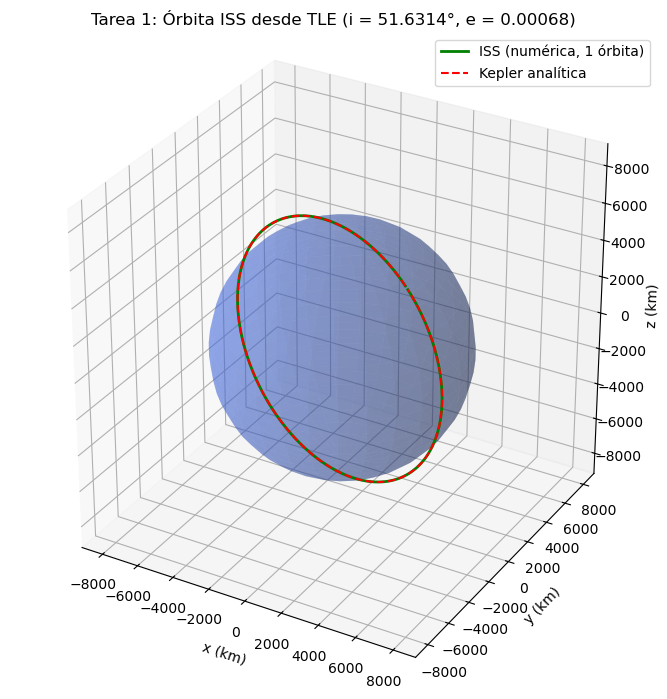

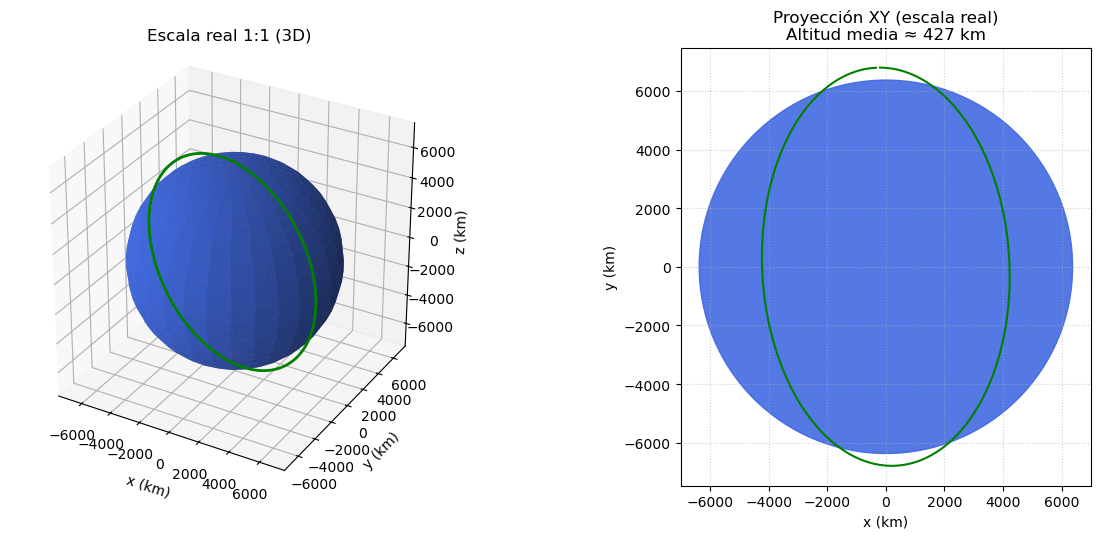

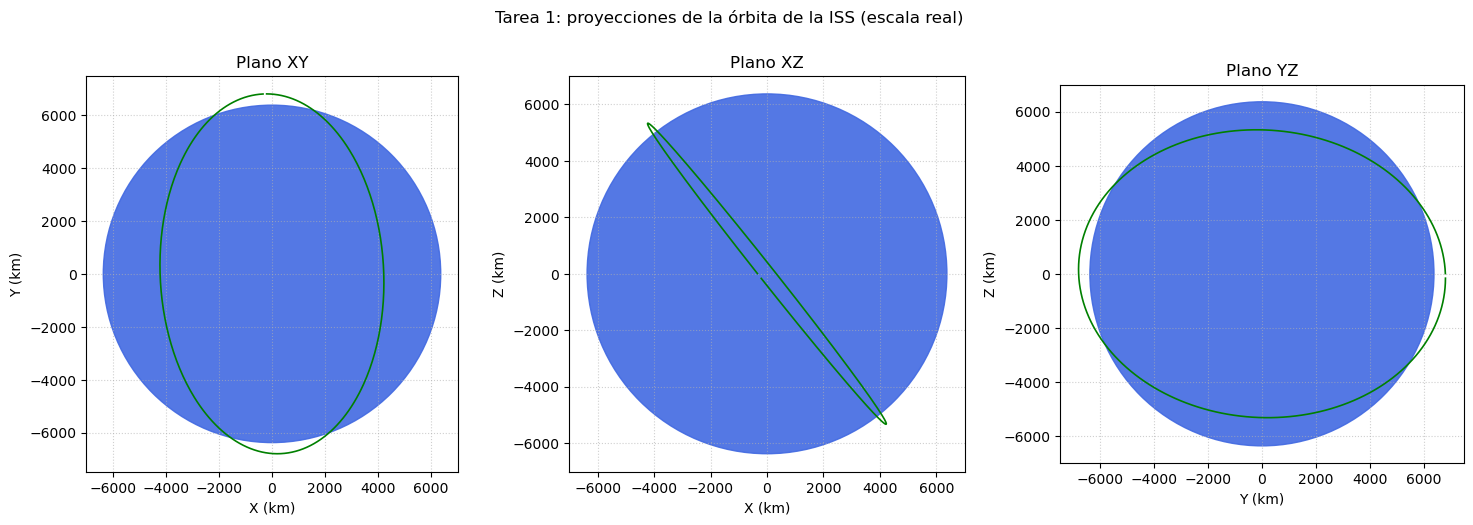

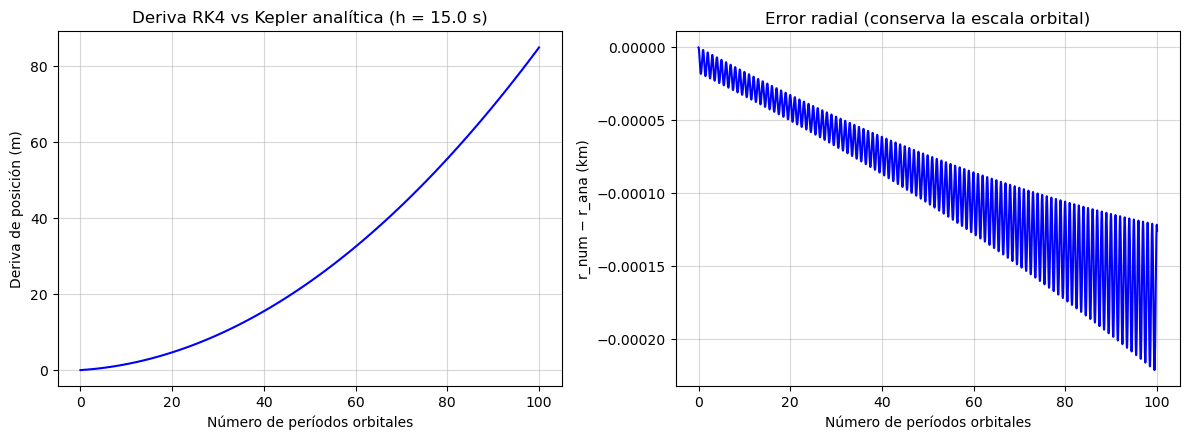

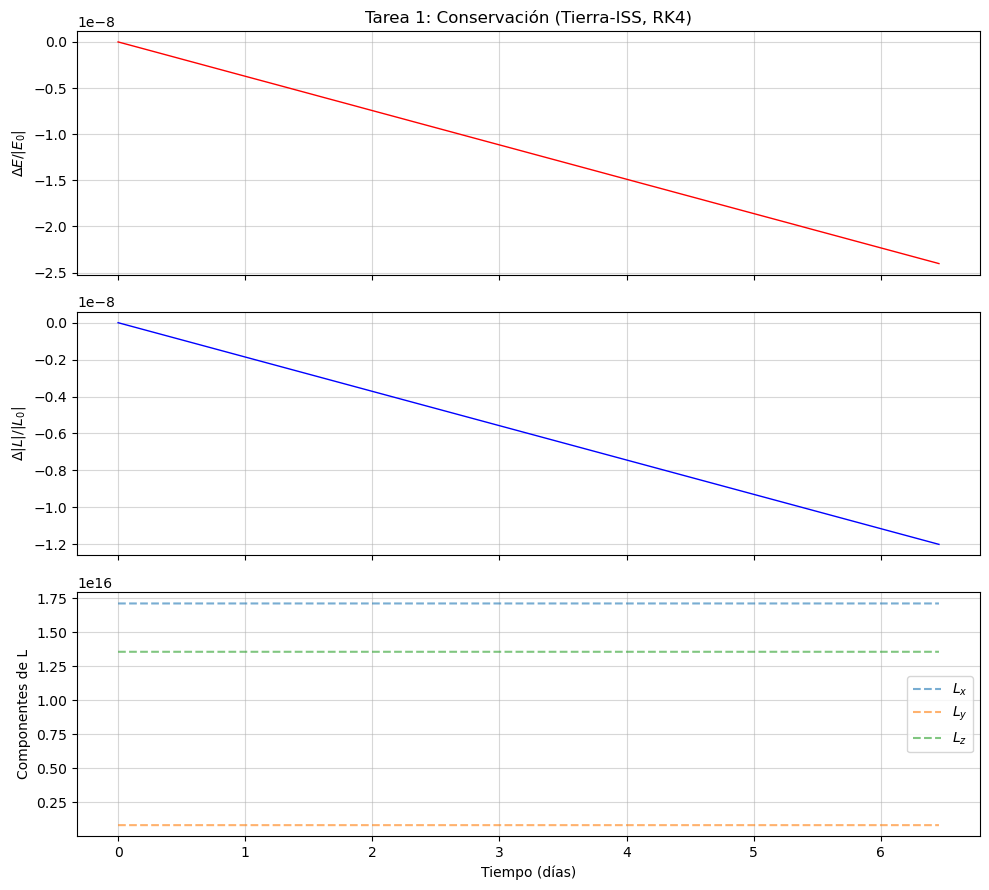

T1 RK4: ΔE/|E0| final = -2.402e-08, Δ|L|/|L0| final = -1.201e-08
Validación 2.ª derivada vs a = -μr/r³ : error relativo medio = 2.379e-05 (máx 2.388e-05)
h =  10.0 s -> deriva final en 100T =     11.708 m
h =  15.0 s -> deriva final en 100T =     84.920 m
h =  30.0 s -> deriva final en 100T =   2590.113 m
h =  60.0 s -> deriva final en 100T =  80889.780 m

|f4| ISS = 8.753e-05 m/s^4 | pendiente log-log medida: p = 4.94 (RK4 ≈ 4)


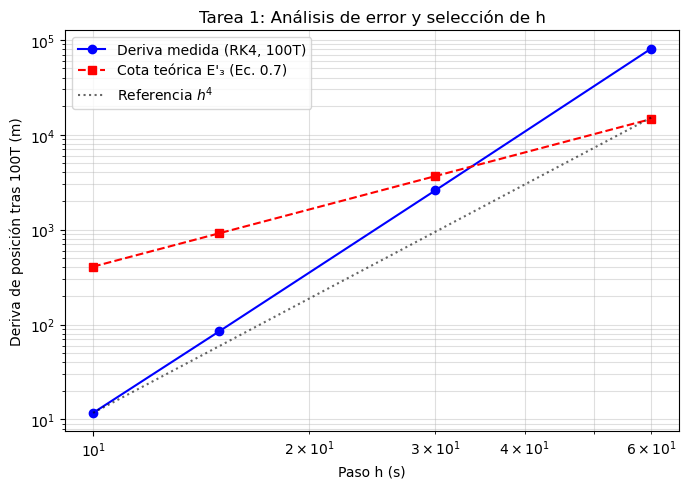

Ápsides: 200 (100 perigeos, 100 apogeos) | espaciado medio 2789.27 s vs T/2 = 2789.27 s
r perigeo medio = 6793.787 km | r apogeo medio = 6802.999 km | (TLE: a(1-e) = 6793.787 km, a(1+e) = 6802.999 km)


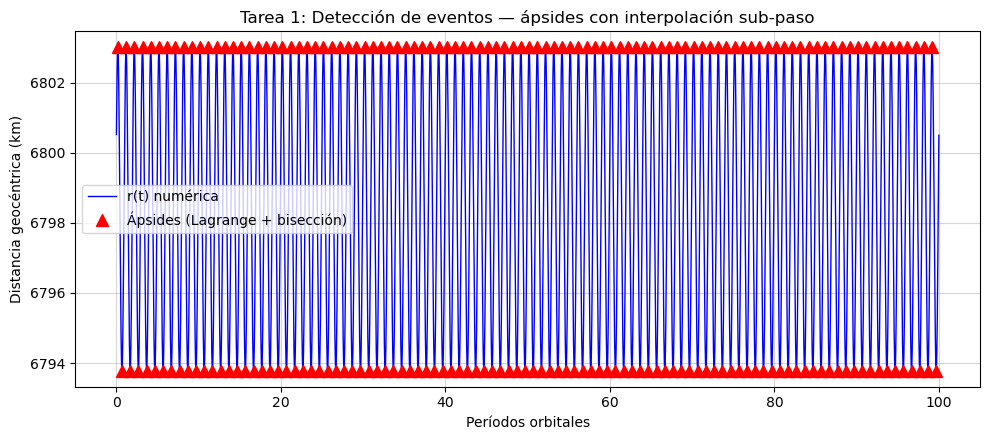

Integrando Tarea 2 (5 cuerpos, 28 días, h = 15.0 s, RK4)...


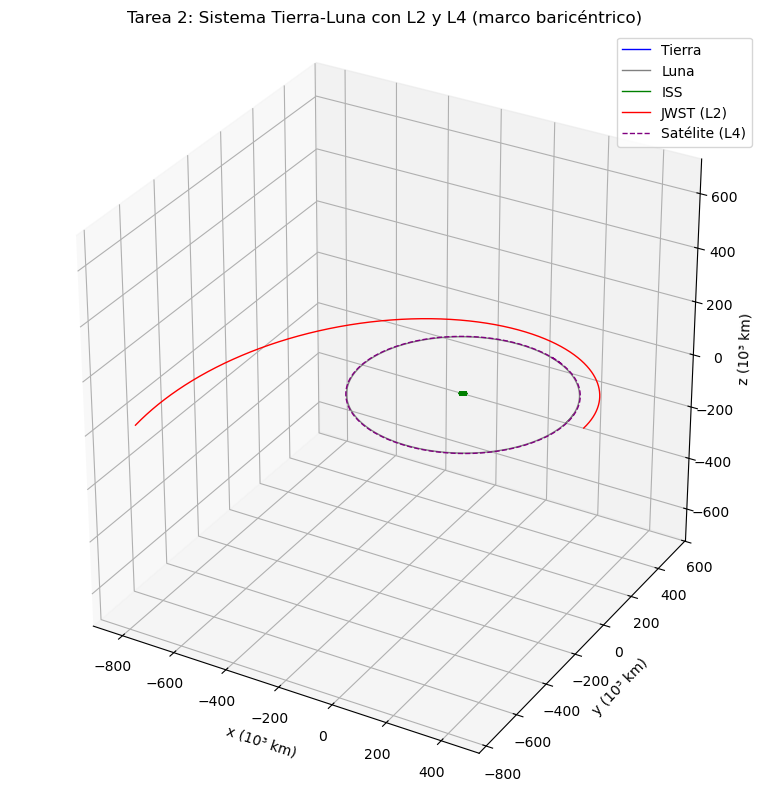

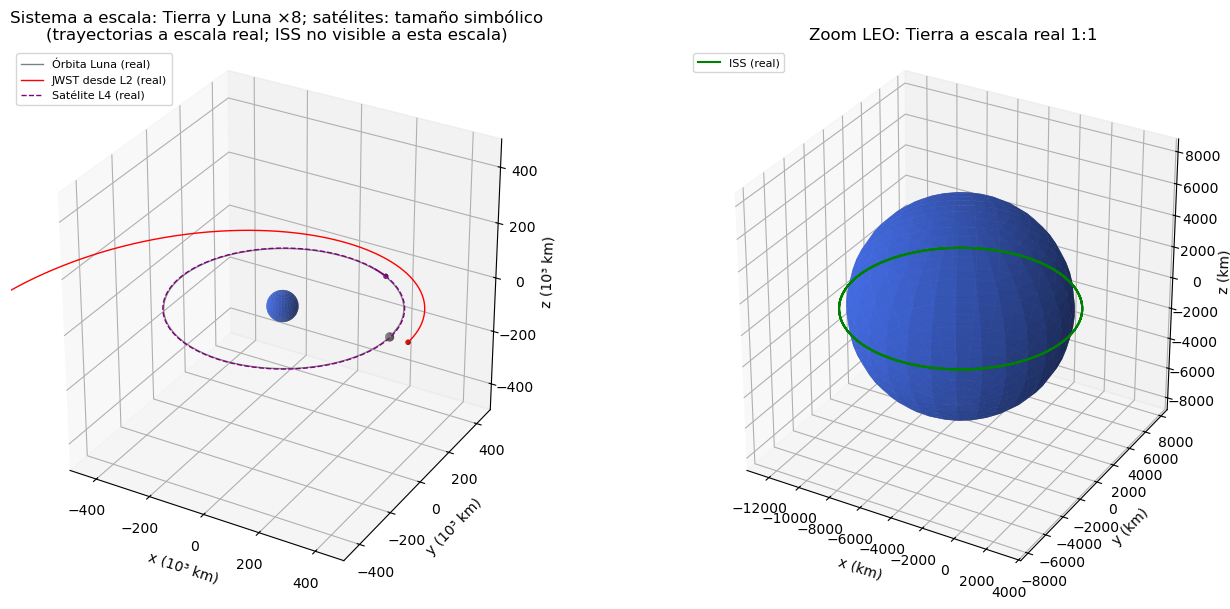

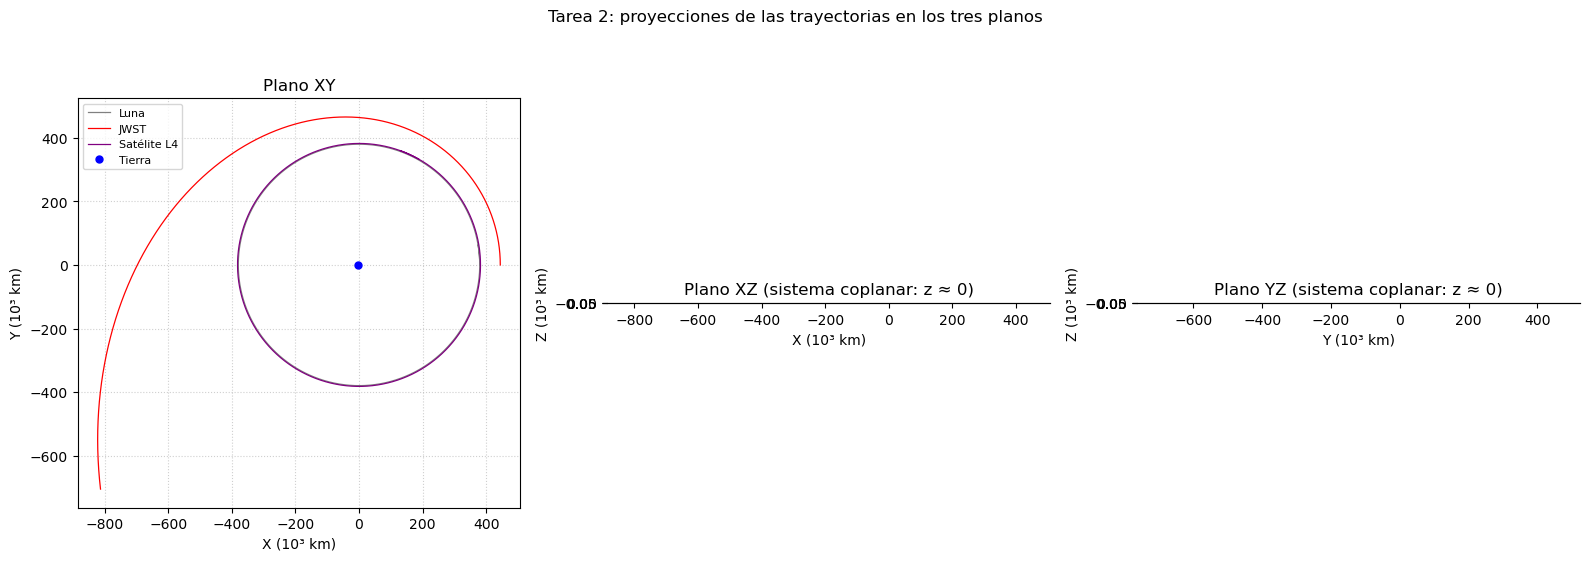

Puntos de Lagrange Tierra-Luna (μ = 0.01214):
  L1: a  326389.7 km de la Tierra y   58010.3 km de la Luna
  L2: a  448904.0 km de la Tierra y   64504.0 km de la Luna
  L3: a  381676.7 km de la Tierra y  766076.7 km de la Luna
  L4: a  384400.0 km de la Tierra y  384400.0 km de la Luna
  L5: a  384400.0 km de la Tierra y  384400.0 km de la Luna


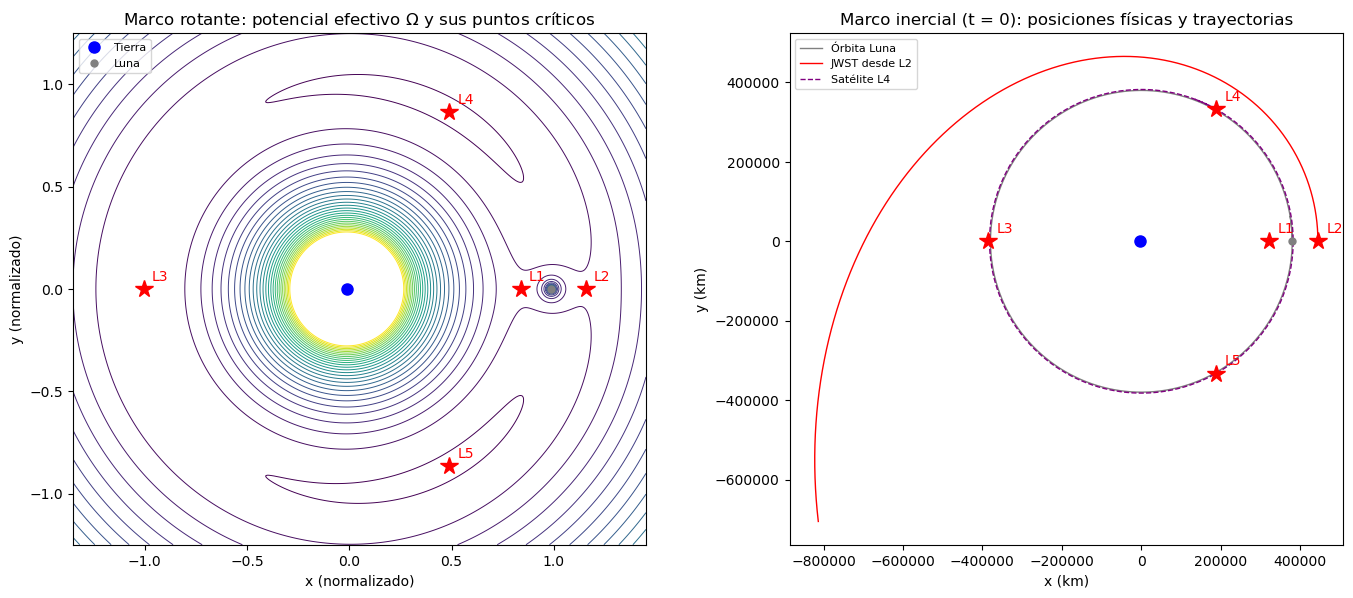

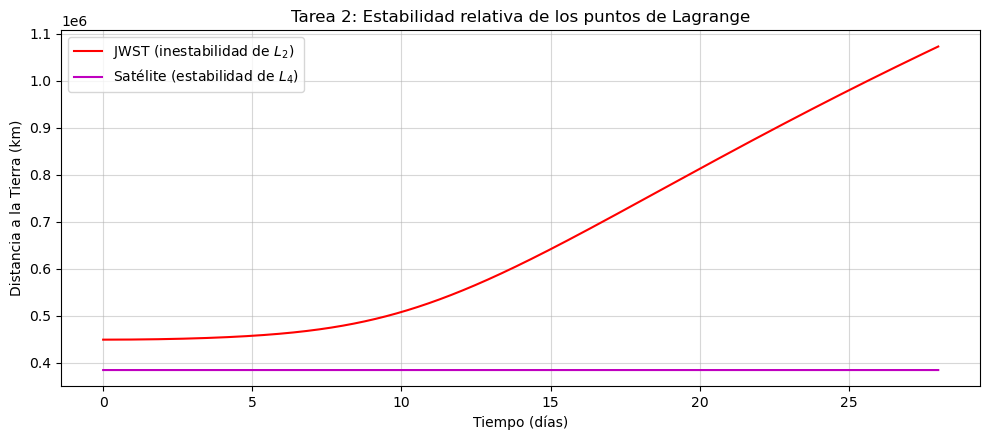

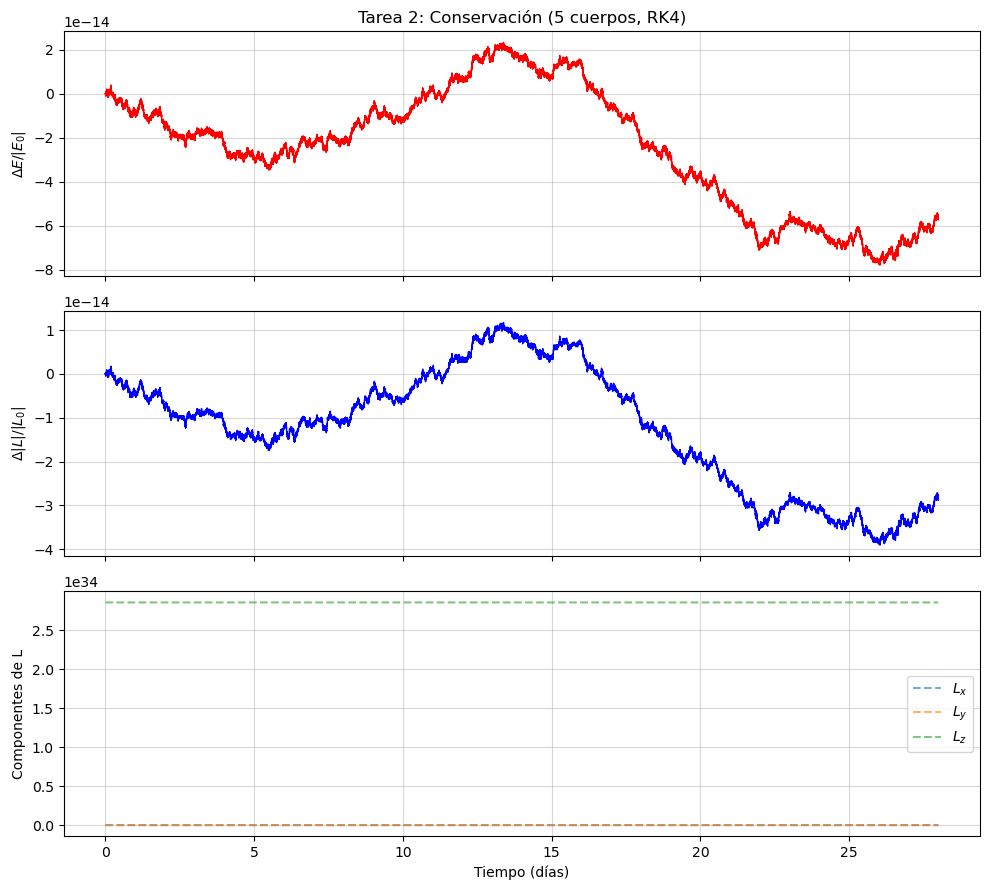

T2 RK4: ΔE/|E0| = -5.731e-14, Δ|L|/|L0| = -2.875e-14
Integrando Tarea 3 (8 cuerpos, 730 días, h = 600.0 s, simpléctico)...


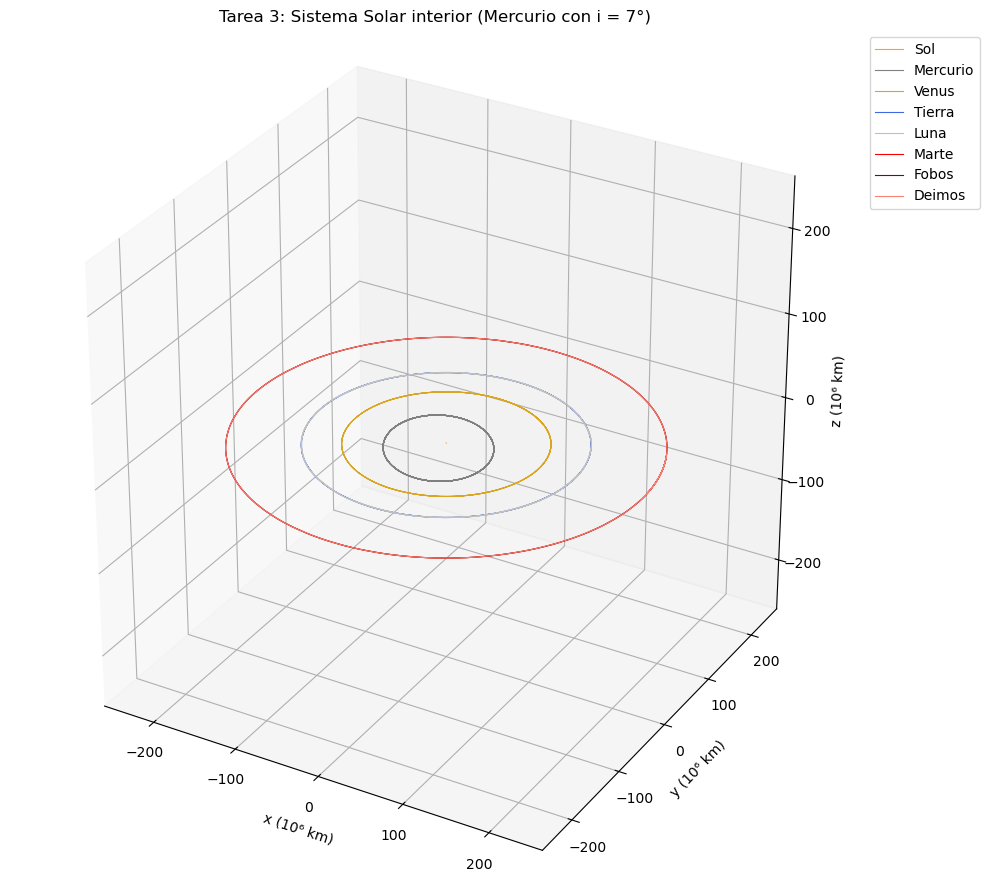

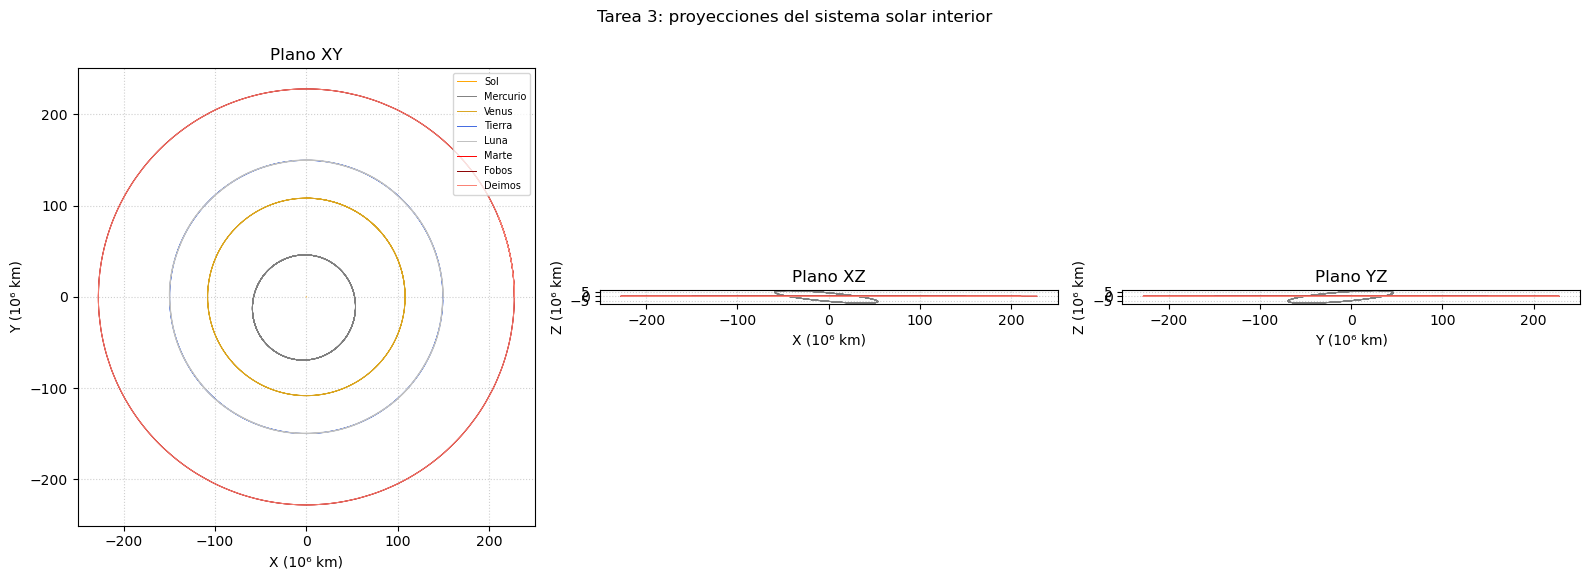

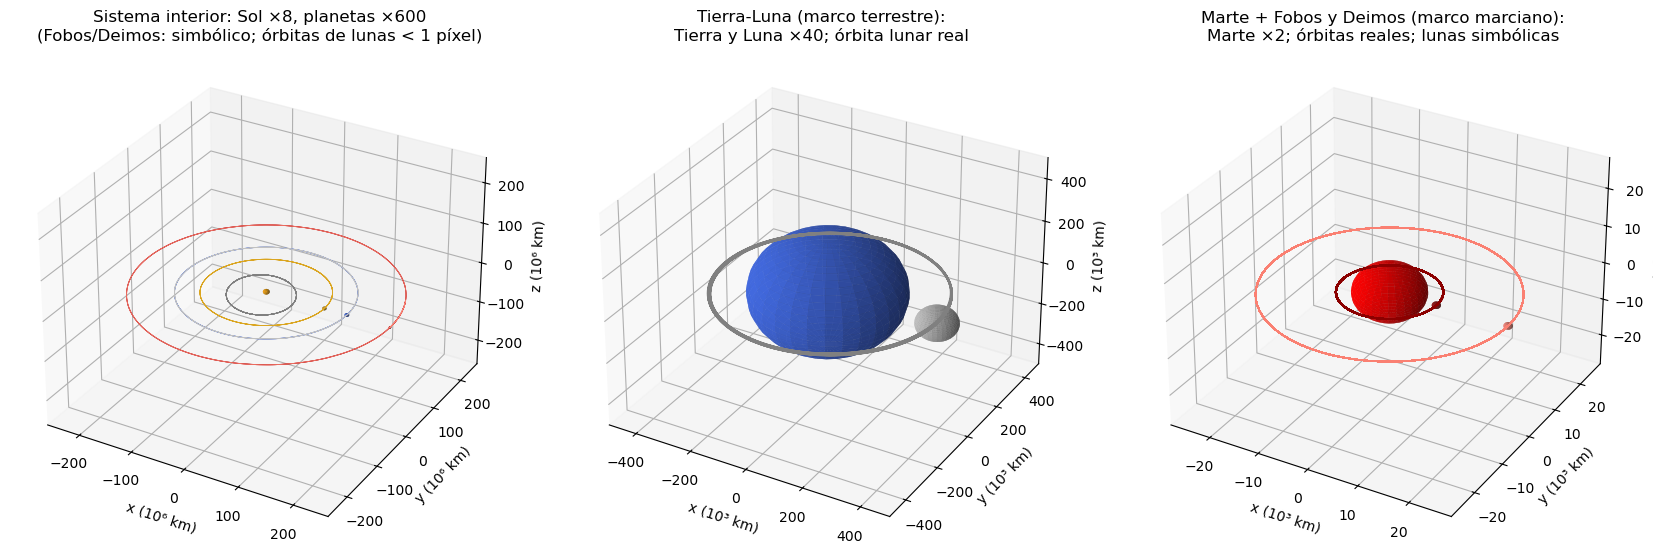

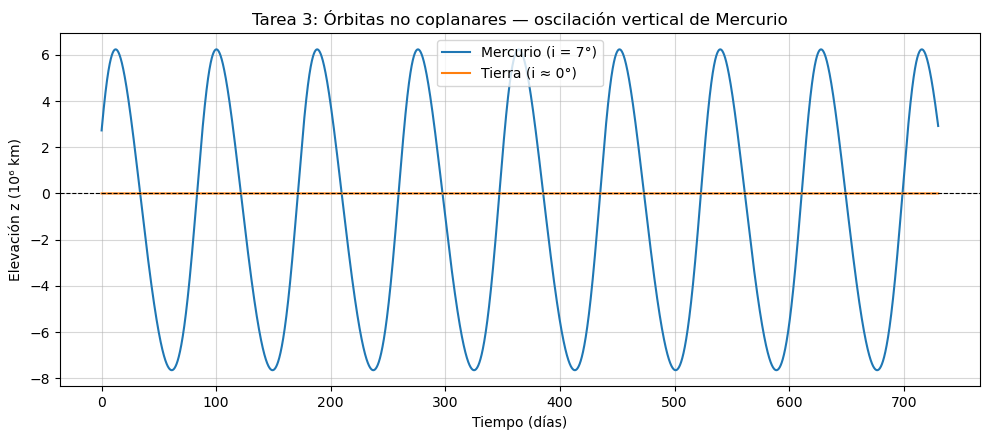

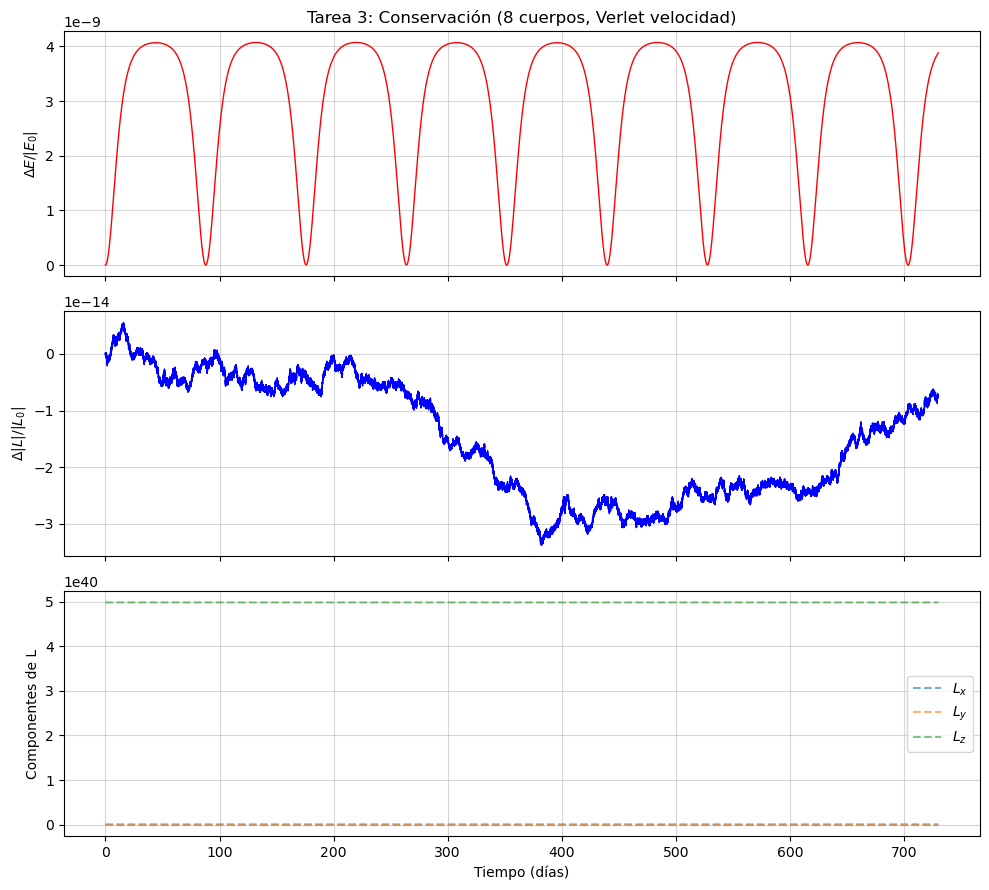

T3 simpléctico: max|ΔE/E0| = 4.073e-09, max|Δ|L|/|L0|| = 3.375e-14
Precesión de ϖ: 1.131e-06 °/día = 148.7 "/siglo | regresión nodal: -471.3 "/siglo
(Referencia: newtoniana total ≈ 532"/siglo con Júpiter; relativista 42.98"/siglo, no modelada)
Integrando versión 2D planar (comparación de la Tarea 3)...
Precesión de ϖ en 2D: 976.4 "/siglo (3D: 148.7 "/siglo)


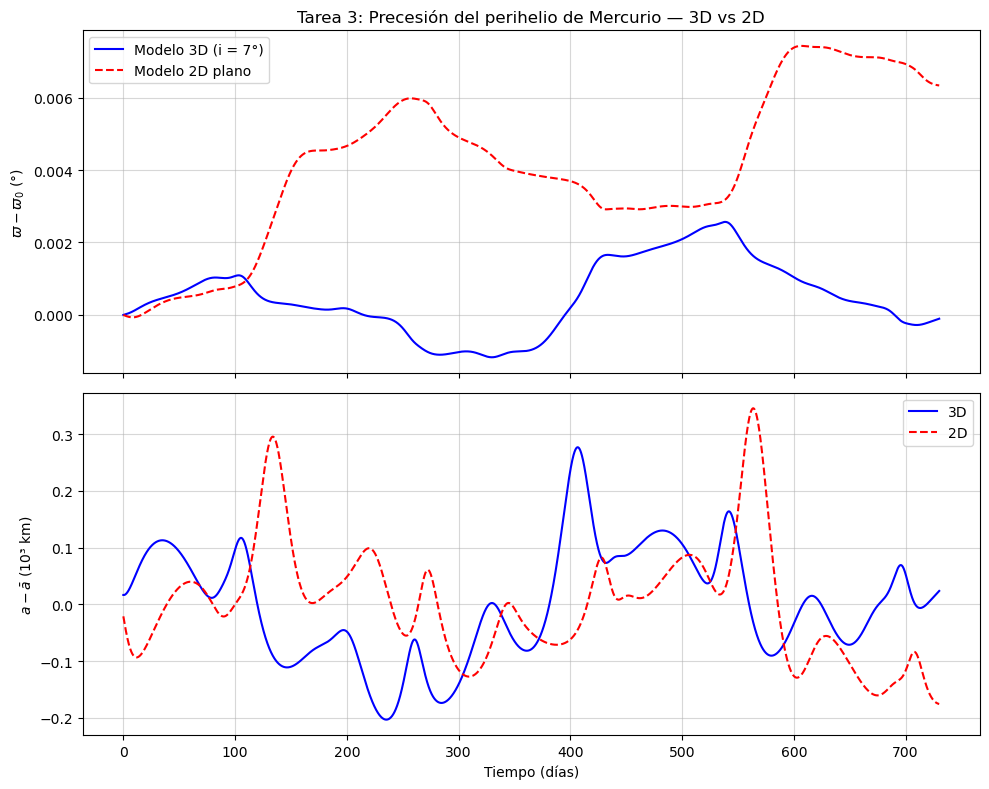

FASE IV — RESUMEN DE VALIDACIÓN

[1] Deriva medida (Tarea 1, 100 períodos) vs cota teórica E'3 (Ec. 0.7):
    h =  10.0 s : medida =     11.708 m | cota E'3 =    406.887 m | razón =  0.02877
    h =  15.0 s : medida =     84.920 m | cota E'3 =    915.495 m | razón =  0.09276
    h =  30.0 s : medida =   2590.113 m | cota E'3 =   3661.979 m | razón =  0.70730
    h =  60.0 s : medida =  80889.780 m | cota E'3 =  14647.917 m | razón =  5.52227
    Pendiente log-log medida: p = 4.94 (RK4 global = h^4)

[2] Justificación de h por tarea (criterio: cuerpo con mayor |f4| = 8·μ²/r⁵):
    |f4| ISS    = 8.75e-05 m/s⁴  -> h = 15 s:  E'3 = 2.46e-02 m/paso
    |f4| Fobos  = 2.02e-07 m/s⁴  (¡crítico en T3, no Mercurio = 2.17e-13!)
    h = 3600 s : E'3 = 787.0 m/paso × 17520 pasos = 13788 km (> radio orbital de Fobos = 9377 km) -> INACEPTABLE
    h =  600 s : E'3 = 3.64 m/paso × 105120 pasos = 383 km (~4% del radio de Fobos) -> h elegido para T3

[3] Conservación (checklist Fase IV):
    T1 (RK4)    

In [27]:
import time

def main():
    print("="*72)
    print("PROGRAMA N-CUERPOS: EJECUCIÓN INTEGRAL (Tareas 1-3 + Fase IV)")
    print("="*72)
    t0 = time.time()
    r1 = ejecutar_tarea_1()
    r2 = ejecutar_tarea_2()
    r3 = ejecutar_tarea_3()
    resumen_fase_iv(r1, r2, r3)
    print(f"\nTiempo total de ejecución: {(time.time()-t0)/60:.1f} min")

if __name__ == "__main__":
    main()